In [3]:
#import packages 

import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc
import numpy as np
from scipy.stats import linregress


In [4]:
data = pd.read_excel('sediment pteropod 13C and 18O data.xlsx', sheet_name = 'OCE205-2-60BC_all+data(all+data', skiprows = 2)
tdata = pd.read_excel('sediment pteropod 13C and 18O data.xlsx', sheet_name = 'tempworkup')
print(tdata.columns)

Index(['Vial', 'Name of Test', 'mean d13C (PDB)', 'mean d18O (PDB)',
       'temp (C°)', 'Sr/Ca [mmol/mol]', 'Ba/Ca [umol/mol]', 'U/Ca [nmol/mol]',
       'Na_Ca [mmol/mol]', 'Mg_Ca [mmol/mol]', 'Mn_Ca [umol/mol]',
       'Fe_Ca [umol/mol]', 'Al_Ca [umol/mol]', 'depth'],
      dtype='object')


In [5]:
#indexdata
o18 = data['mean d18O (PDB)']
c13 = data['mean d13C (PDB)']


datacsv = "Sediment_O18C13.csv"
data.to_csv(datacsv, index=False)
datacsv = pd.read_csv(datacsv)

noclean = datacsv[datacsv['Name of Test'].str.contains('No cleaning')]
sonic = datacsv[datacsv['Name of Test'].str.contains('Sonicate ')]
redsonic = datacsv[datacsv['Name of Test'].str.contains('Sonicate+red', regex=False)]
oxredsonic = datacsv[datacsv['Name of Test'].str.contains('Sonicate++red+ox', regex=False)]

nocleano = noclean['mean d18O (PDB)']
sonico = sonic['mean d18O (PDB)']
redsonico = redsonic['mean d18O (PDB)']
oxredsonico = oxredsonic['mean d18O (PDB)']

nocleanc = noclean['mean d13C (PDB)']
sonicc = sonic['mean d13C (PDB)']
redsonicc = redsonic['mean d13C (PDB)']
oxredsonicc = oxredsonic['mean d13C (PDB)']


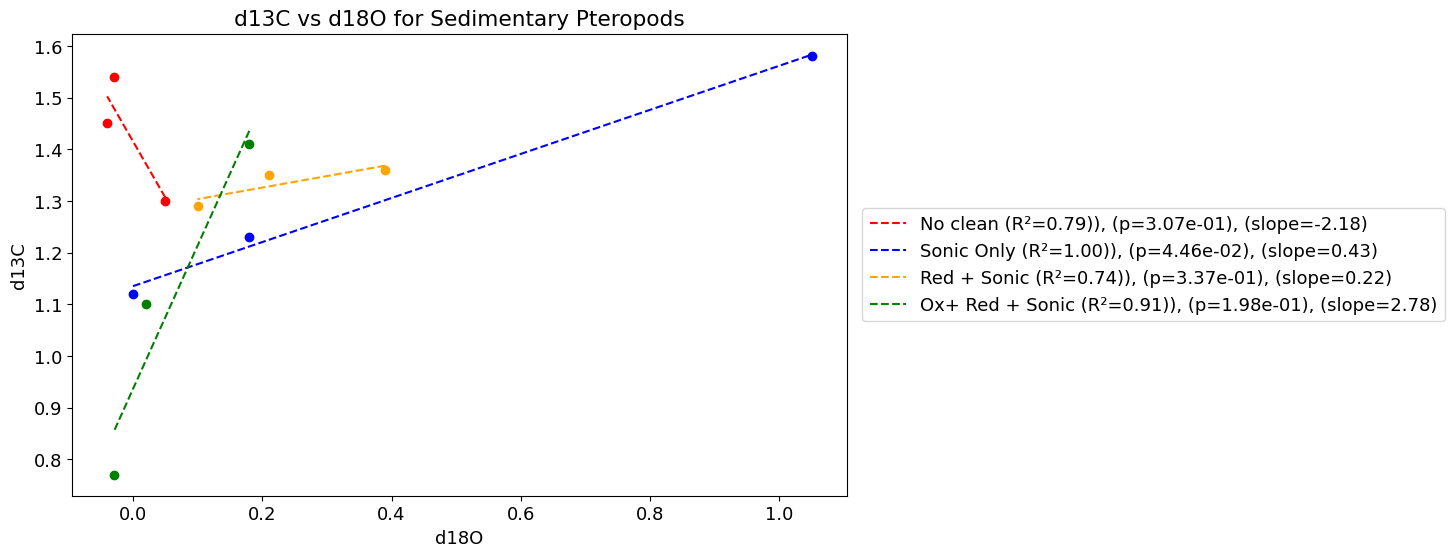

In [6]:
#graph 1 : c13 vs o18

# calulate linear regression
#no clean
slopeCO, interceptCO, r_valueCO, p_valueCO, std_errCO = linregress(nocleano, nocleanc)
regression_yCO = slopeCO * nocleano + interceptCO
r_squaredCO = r_valueCO**2

#sonic only
slopesonicCO, interceptsonicCO, r_valuesonicCO, p_valuesonicCO, std_errsonicCO = linregress(sonico, sonicc)
regression_ysonicCO = slopesonicCO * sonico + interceptsonicCO
r_squaredsonicCO = r_valuesonicCO**2

#sonic+red
sloperedCO, interceptredCO, r_valueredCO, p_valueredCO, std_errredCO = linregress(redsonico, redsonicc)
regression_yredCO = sloperedCO * redsonico + interceptredCO
r_squaredredCO = r_valueredCO**2

#sonic+red+ox
sloperedoxCO, interceptredoxCO, r_valueredoxCO, p_valueredoxCO, std_errredoxCO = linregress(oxredsonico, oxredsonicc)
regression_yredoxCO = sloperedoxCO * oxredsonico + interceptredoxCO
r_squaredredoxCO = r_valueredoxCO**2

#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(nocleano, nocleanc, color = 'r')
plt.scatter(sonico, sonicc, color = 'b')
plt.scatter(redsonico, redsonicc, color = 'orange')
plt.scatter(oxredsonico, oxredsonicc, color = 'green')

#plot linear regression
#noclean
plt.plot(nocleano, regression_yCO, label=f'No clean (R²={r_squaredCO:.2f})), (p={p_valueCO:.2e}), (slope={slopeCO:.2f})', color='r', linestyle='--')
#sonic only
plt.plot(sonico, regression_ysonicCO, label=f'Sonic Only (R²={r_squaredsonicCO:.2f})), (p={p_valuesonicCO:.2e}), (slope={slopesonicCO:.2f})', color='b', linestyle='--')
#red+sonic
plt.plot(redsonico, regression_yredCO, label=f'Red + Sonic (R²={r_squaredredCO:.2f})), (p={p_valueredCO:.2e}), (slope={sloperedCO:.2f})', color='orange', linestyle='--')
#ox+red+sonic
plt.plot(oxredsonico, regression_yredoxCO, label=f'Ox+ Red + Sonic (R²={r_squaredredoxCO:.2f})), (p={p_valueredoxCO:.2e}), (slope={sloperedoxCO:.2f})', color='green', linestyle='--')


# axis labels 
plt.xlabel('d18O')
plt.ylabel('d13C')

#plot title
plt.title('d13C vs d18O for Sedimentary Pteropods')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)






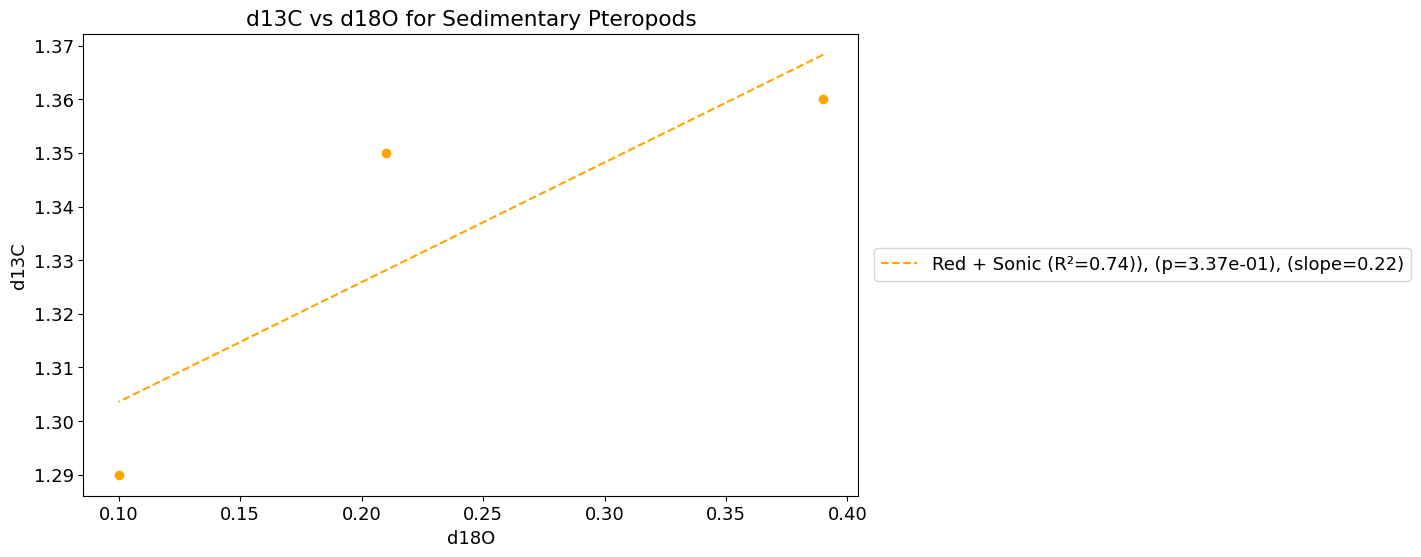

In [7]:
#graph 1 : c13 vs o18 for redsonic

# calulate linear regression
#sonic+red
sloperedCO, interceptredCO, r_valueredCO, p_valueredCO, std_errredCO = linregress(redsonico, redsonicc)
regression_yredCO = sloperedCO * redsonico + interceptredCO
r_squaredredCO = r_valueredCO**2



#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(redsonico, redsonicc, color = 'orange')


#plot linear regression
#redsonic
plt.plot(redsonico, regression_yredCO, label=f'Red + Sonic (R²={r_squaredredCO:.2f})), (p={p_valueredCO:.2e}), (slope={sloperedCO:.2f})', color='orange', linestyle='--')




# axis labels 
plt.xlabel('d18O')
plt.ylabel('d13C')

#plot title
plt.title('d13C vs d18O for Sedimentary Pteropods')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)






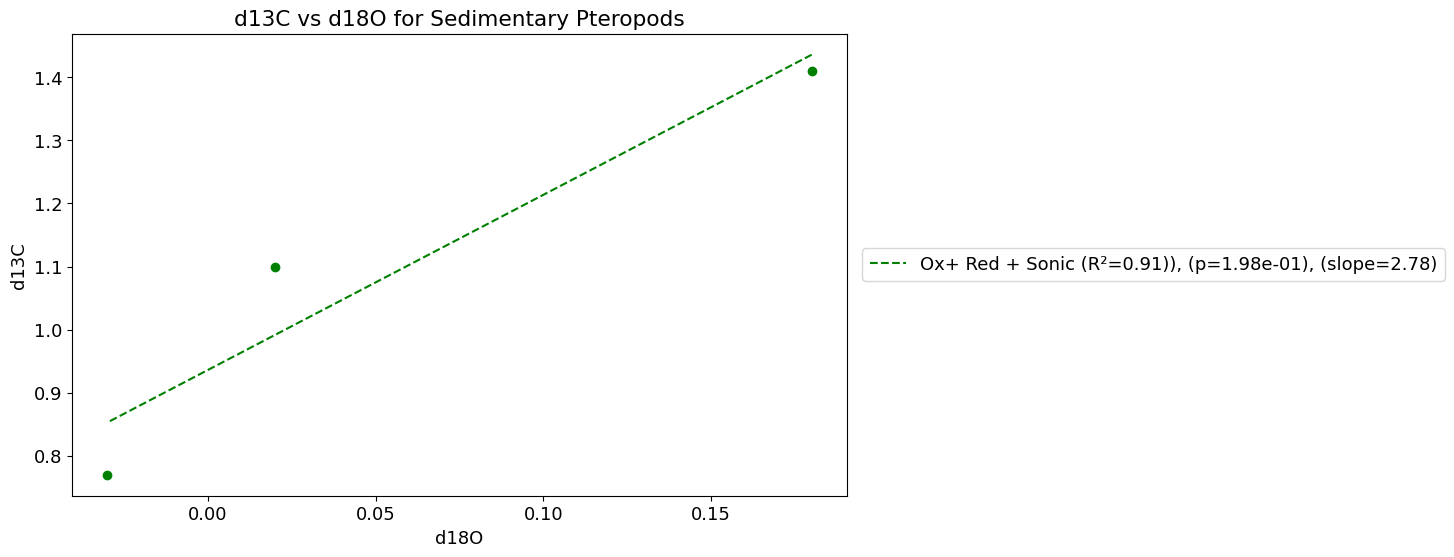

In [8]:
#graph 2: c13 vs o18 for oxredsonic

# calulate linear regression

#sonic+red+ox
sloperedoxCO, interceptredoxCO, r_valueredoxCO, p_valueredoxCO, std_errredoxCO = linregress(oxredsonico, oxredsonicc)
regression_yredoxCO = sloperedoxCO * oxredsonico + interceptredoxCO
r_squaredredoxCO = r_valueredoxCO**2

#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(oxredsonico, oxredsonicc, color = 'green')

#plot linear regression
#oxredsonic
plt.plot(oxredsonico, regression_yredoxCO, label=f'Ox+ Red + Sonic (R²={r_squaredredoxCO:.2f})), (p={p_valueredoxCO:.2e}), (slope={sloperedoxCO:.2f})', color='green', linestyle='--')


# axis labels 
plt.xlabel('d18O')
plt.ylabel('d13C')

#plot title
plt.title('d13C vs d18O for Sedimentary Pteropods')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)






/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_73907/73617123.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)


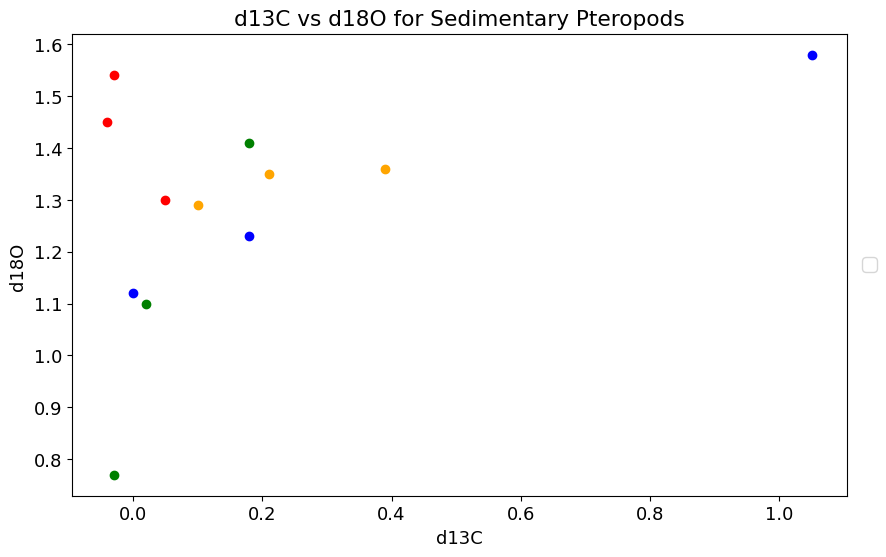

In [9]:
#graph 3 : c13 vs o18

# calulate linear regression
#no clean
slopeCO, interceptCO, r_valueCO, p_valueCO, std_errCO = linregress(nocleano, nocleanc)
regression_yCO = slopeCO * nocleano + interceptCO
r_squaredCO = r_valueCO**2

#sonic only
slopesonicCO, interceptsonicCO, r_valuesonicCO, p_valuesonicCO, std_errsonicCO = linregress(sonico, sonicc)
regression_ysonicCO = slopesonicCO * sonico + interceptsonicCO
r_squaredsonicCO = r_valuesonicCO**2

#sonic+red
sloperedCO, interceptredCO, r_valueredCO, p_valueredCO, std_errredCO = linregress(redsonico, redsonicc)
regression_yredCO = sloperedCO * redsonico + interceptredCO
r_squaredredCO = r_valueredCO**2

#sonic+red+ox
sloperedoxCO, interceptredoxCO, r_valueredoxCO, p_valueredoxCO, std_errredoxCO = linregress(oxredsonico, oxredsonicc)
regression_yredoxCO = sloperedoxCO * oxredsonico + interceptredoxCO
r_squaredredoxCO = r_valueredoxCO**2

#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(nocleano, nocleanc, color = 'r')
plt.scatter(sonico, sonicc, color = 'b')
plt.scatter(redsonico, redsonicc, color = 'orange')
plt.scatter(oxredsonico, oxredsonicc, color = 'green')



# axis labels 
plt.ylabel('d18O ')
plt.xlabel('d13C')

#plot title
plt.title('d13C vs d18O for Sedimentary Pteropods')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)






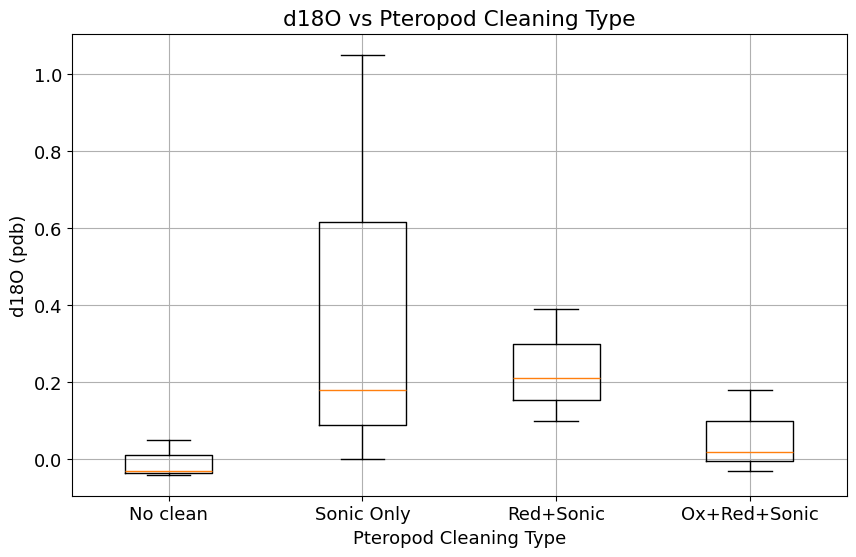

In [10]:
# graph 4: box plot for o18

allo18 = nocleano, sonico, redsonico, oxredsonico
labelall = 'No clean', 'Sonic Only', 'Red+Sonic', 'Ox+Red+Sonic'
#create figure
plt.figure(figsize=(10,6))

plt.boxplot(allo18, tick_labels = labelall)

plt.xlabel('Pteropod Cleaning Type')
plt.ylabel('d18O (pdb)')
plt.title('d18O vs Pteropod Cleaning Type')
plt.grid()

0    1.30
1    1.54
2    1.45
Name: mean d13C (PDB), dtype: float64
9     1.41
10    1.10
11    0.77
Name: mean d13C (PDB), dtype: float64


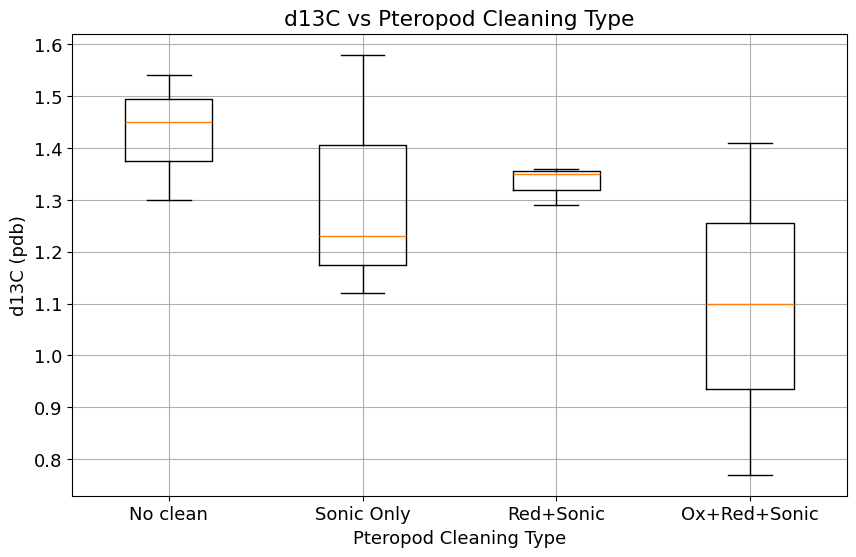

In [11]:
# graph 5: box plot for o18
print(nocleanc)
print(oxredsonicc)
allc13 = nocleanc, sonicc, redsonicc, oxredsonicc
labelall = 'No clean', 'Sonic Only', 'Red+Sonic', 'Ox+Red+Sonic'
#create figure
plt.figure(figsize=(10,6))

plt.boxplot(allc13, tick_labels = labelall)

plt.xlabel('Pteropod Cleaning Type')
plt.ylabel('d13C (pdb)')
plt.title('d13C vs Pteropod Cleaning Type')
plt.grid()

Text(0.5, 1.0, 'd18O (PDB) vs Temperature')

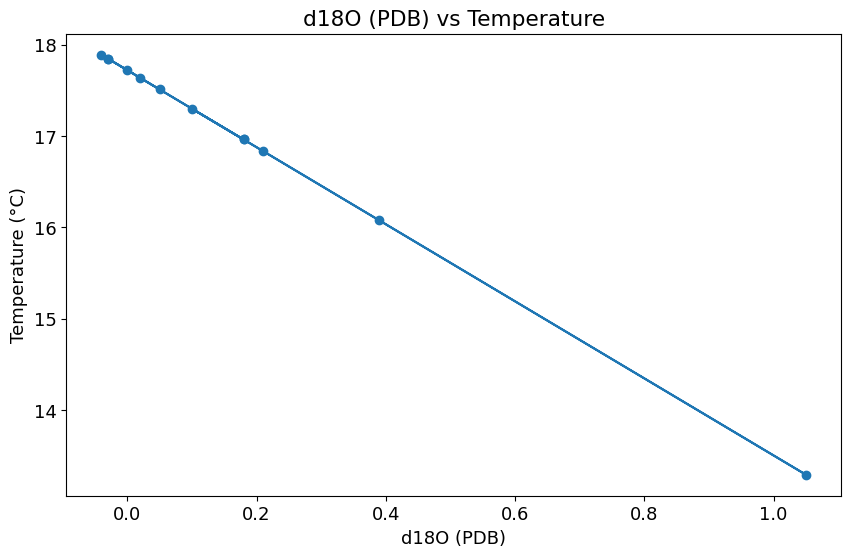

In [12]:
#graph 6: 18O vs Temp

#index variables
O18 = tdata['mean d18O (PDB)']
t = tdata['temp (C°)']

#create figure
plt.figure(figsize = (10,6))

#plot data
plt.plot(O18, t)
plt.scatter(O18, t)

#plot axes
plt.xlabel('d18O (PDB)')
plt.ylabel('Temperature (°C)')
plt.title('d18O (PDB) vs Temperature')

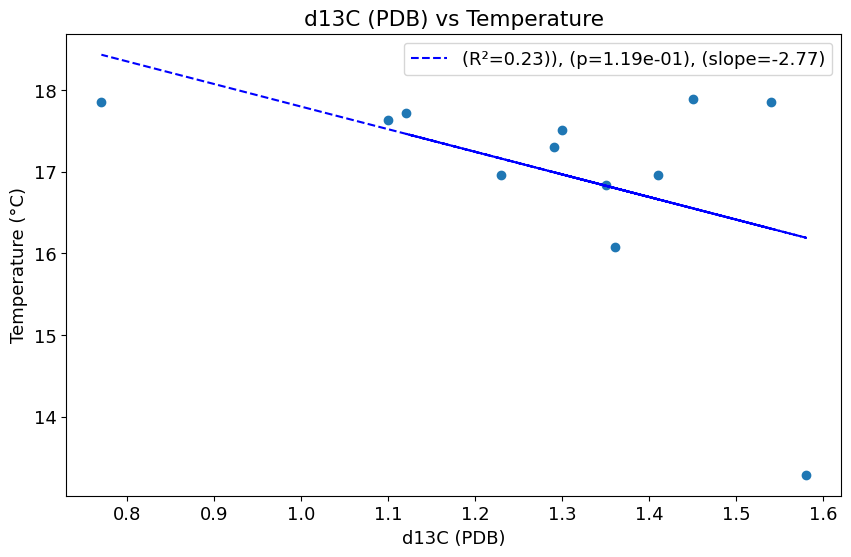

In [13]:
#graph 7: 13C vs temp

#index variable 
C13 = tdata['mean d13C (PDB)']

#create figure
plt.figure(figsize = (10,6))

#plot data
plt.scatter(C13, t)

#sonic+red+ox
slopeC, interceptC, r_valueC, p_valueC, std_errC = linregress(C13, t)
regression_yC = slopeC * C13 + interceptC
r_squaredC = r_valueC**2

plt.plot(C13, regression_yC, label=f'(R²={r_squaredC:.2f})), (p={p_valueC:.2e}), (slope={slopeC:.2f})', color='b', linestyle='--')

#plot axes
plt.xlabel('d13C (PDB)')
plt.ylabel('Temperature (°C)')
plt.title('d13C (PDB) vs Temperature')
plt.legend()



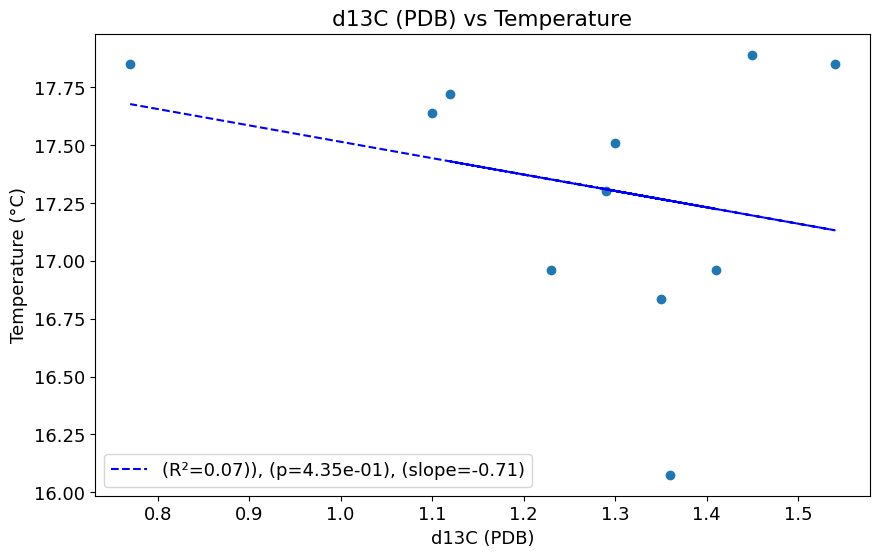

In [14]:
#graph 8: 13C vs temp w/o outlier

out = tdata.drop(tdata.index[5])

#index variable 
C13out = out['mean d13C (PDB)']
tout = out['temp (C°)']
 
#create figure
plt.figure(figsize = (10,6))

#plot data
plt.scatter(C13out, tout)

#out linear regression
slopeCout, interceptCout, r_valueCout, p_valueCout, std_errCout = linregress(C13out, tout)
regression_yCout = slopeCout * C13out + interceptCout
r_squaredCout = r_valueCout**2

#plot linear regression
plt.plot(C13out, regression_yCout, label=f'(R²={r_squaredCout:.2f})), (p={p_valueCout:.2e}), (slope={slopeCout:.2f})', color='b', linestyle='--')

#plot axes
plt.xlabel('d13C (PDB)')
plt.ylabel('Temperature (°C)')
plt.title('d13C (PDB) vs Temperature')
plt.legend()




In [15]:
#extracting correct data
tdatacsv = "Sediment_O18C13T.csv"
tdata.to_csv(tdatacsv, index=False)
tdatacsv = pd.read_csv(tdatacsv)

#index by cleaning type
noclean = tdatacsv[tdatacsv['Name of Test'].str.contains('No cleaning')]
sonic = tdatacsv[tdatacsv['Name of Test'].str.contains('Sonicate ')]
redsonic = tdatacsv[tdatacsv['Name of Test'].str.contains('Sonicate+red', regex=False)]
oxredsonic = tdatacsv[tdatacsv['Name of Test'].str.contains('Sonicate++red+ox', regex=False)]

#index 18O by cleaning type
nocleano = noclean['mean d18O (PDB)']
sonico = sonic['mean d18O (PDB)']
redsonico = redsonic['mean d18O (PDB)']
oxredsonico = oxredsonic['mean d18O (PDB)']

#index 13C by cleaning type
nocleanc = noclean['mean d13C (PDB)']
sonicc = sonic['mean d13C (PDB)']
redsonicc = redsonic['mean d13C (PDB)']
oxredsonicc = oxredsonic['mean d13C (PDB)']

#index temperature by cleaning type
nocleant = noclean['temp (C°)']
sonict = sonic['temp (C°)']
redsonict = redsonic['temp (C°)']
oxredsonict = oxredsonic['temp (C°)']

#pull out all Me/Ca ratios for all cleaning types 
tSr = tdata['Sr/Ca [mmol/mol]']
tBa = tdata['Ba/Ca [umol/mol]']
tU = tdata['U/Ca [nmol/mol]']
tNa = tdata['Na_Ca [mmol/mol]']
tMg = tdata['Mg_Ca [mmol/mol]']
tMn = tdata['Mn_Ca [umol/mol]']
tFe = tdata['Fe_Ca [umol/mol]']
tAl = tdata['Al_Ca [umol/mol]']

#pull out me/ca ratios for red+sonic
Srred = redsonic['Sr/Ca [mmol/mol]']
Bared = redsonic['Ba/Ca [umol/mol]']
Ured = redsonic['U/Ca [nmol/mol]']
Nared = redsonic['Na_Ca [mmol/mol]']
Mgred = redsonic['Mg_Ca [mmol/mol]']
Mnred = redsonic['Mn_Ca [umol/mol]']
Fered = redsonic['Fe_Ca [umol/mol]']
Alred = redsonic['Al_Ca [umol/mol]']

#pull out me/ca ratios for ox+red+sonic
Srredox = oxredsonic['Sr/Ca [mmol/mol]']
Baredox = oxredsonic['Ba/Ca [umol/mol]']
Uredox = oxredsonic['U/Ca [nmol/mol]']
Naredox = oxredsonic['Na_Ca [mmol/mol]']
Mgredox = oxredsonic['Mg_Ca [mmol/mol]']
Mnredox = oxredsonic['Mn_Ca [umol/mol]']
Feredox = oxredsonic['Fe_Ca [umol/mol]']
Alredox = oxredsonic['Al_Ca [umol/mol]']




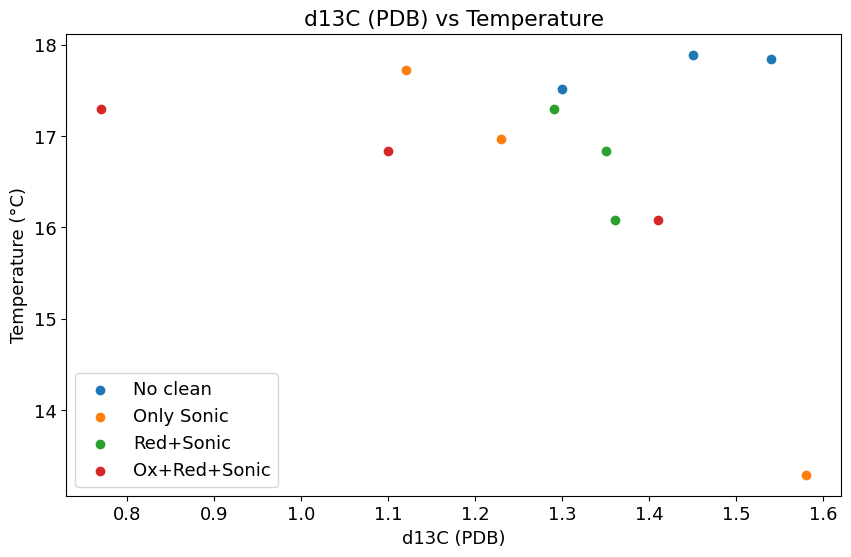

In [16]:
#graph 9: 13C vs temp w/o outlier
 
#create figure
plt.figure(figsize = (10,6))

#plot data
plt.scatter(nocleanc, nocleant, label = 'No clean')
plt.scatter(sonicc, sonict, label = 'Only Sonic')
plt.scatter(redsonicc, redsonict, label = 'Red+Sonic')
plt.scatter(oxredsonicc, redsonict, label = 'Ox+Red+Sonic')


#plot axes
plt.xlabel('d13C (PDB)')
plt.ylabel('Temperature (°C)')
plt.title('d13C (PDB) vs Temperature')
plt.legend()



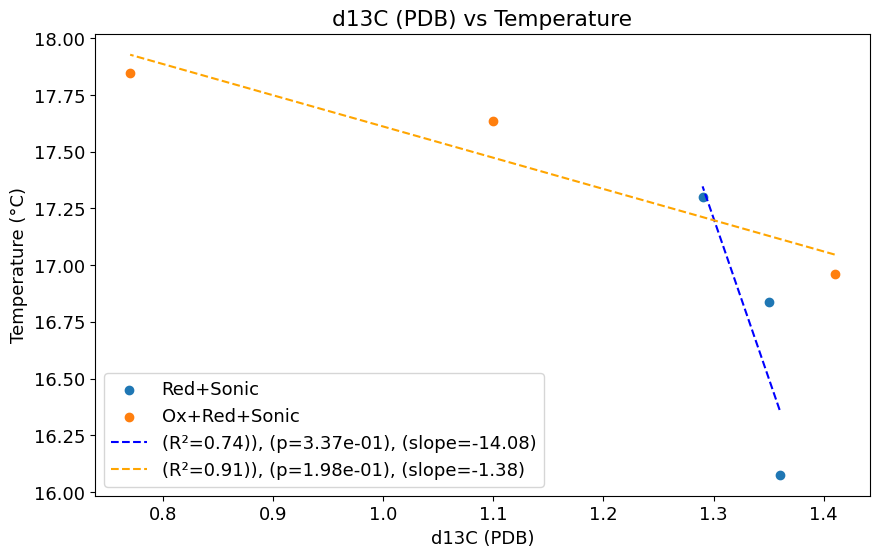

In [17]:
#graph 10: 13C vs temp w/o outlier
 
#create figure
plt.figure(figsize = (10,6))

#plot data
plt.scatter(redsonicc, redsonict, label = 'Red+Sonic')
plt.scatter(oxredsonicc, oxredsonict, label = 'Ox+Red+Sonic')

#sonic+red
slopered, interceptred, r_valuered, p_valuered, std_errred = linregress(redsonicc, redsonict)
regression_yred = slopered * redsonicc + interceptred
r_squaredred = r_valuered**2

plt.plot(redsonicc, regression_yred, label=f'(R²={r_squaredred:.2f})), (p={p_valuered:.2e}), (slope={slopered:.2f})', color='b', linestyle='--')


#sonic+red+ox
sloperedox, interceptredox, r_valueredox, p_valueredox, std_errredox = linregress(oxredsonicc, oxredsonict)
regression_yredox = sloperedox * oxredsonicc + interceptredox
r_squaredredox = r_valueredox**2

plt.plot(oxredsonicc, regression_yredox, label=f'(R²={r_squaredredox:.2f})), (p={p_valueredox:.2e}), (slope={sloperedox:.2f})', color='orange', linestyle='--')

#plot axes
plt.xlabel('d13C (PDB)')
plt.ylabel('Temperature (°C)')
plt.title('d13C (PDB) vs Temperature')
plt.legend()



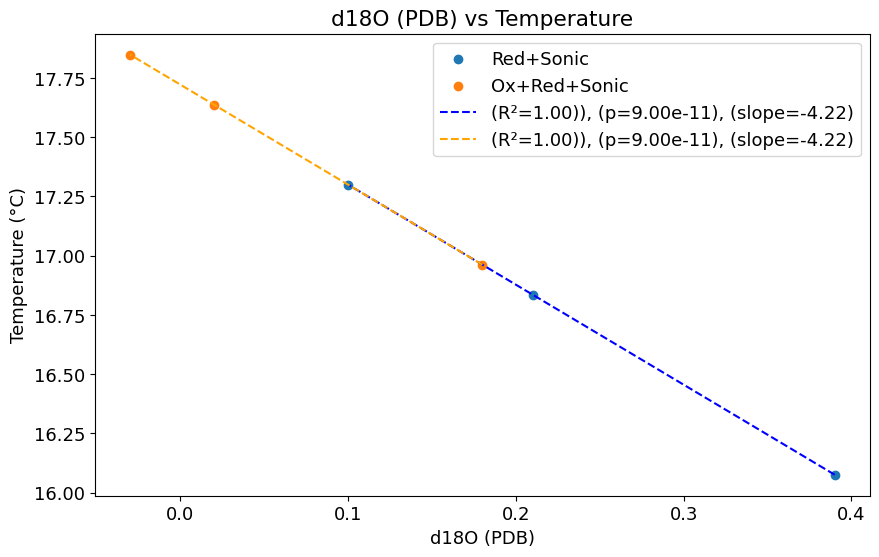

In [18]:
#graph 11: 18C vs temp
 
#create figure
plt.figure(figsize = (10,6))

#plot data
plt.scatter(redsonico, redsonict, label = 'Red+Sonic')
plt.scatter(oxredsonico, oxredsonict, label = 'Ox+Red+Sonic')

#sonic+red
sloperedo, interceptredo, r_valueredo, p_valueredo, std_errredo = linregress(redsonico, redsonict)
regression_yredo = sloperedo * redsonico + interceptredo
r_squaredredo = r_valueredo**2

plt.plot(redsonico, regression_yredo, label=f'(R²={r_squaredredo:.2f})), (p={p_valueredo:.2e}), (slope={sloperedo:.2f})', color='b', linestyle='--')


#sonic+red+ox
sloperedoxo, interceptredoxo, r_valueredoxo, p_valueredoxo, std_errredoxo = linregress(oxredsonico, oxredsonict)
regression_yredoxo = sloperedoxo * oxredsonico + interceptredoxo
r_squaredredoxo = r_valueredoxo**2

plt.plot(oxredsonico, regression_yredoxo, label=f'(R²={r_squaredredoxo:.2f})), (p={p_valueredoxo:.2e}), (slope={sloperedoxo:.2f})', color='orange', linestyle='--')

#plot axes
plt.xlabel('d18O (PDB)')
plt.ylabel('Temperature (°C)')
plt.title('d18O (PDB) vs Temperature')
plt.legend()



Text(0.5, 1.0, 'd13C of Pteropod Cleaning Types')

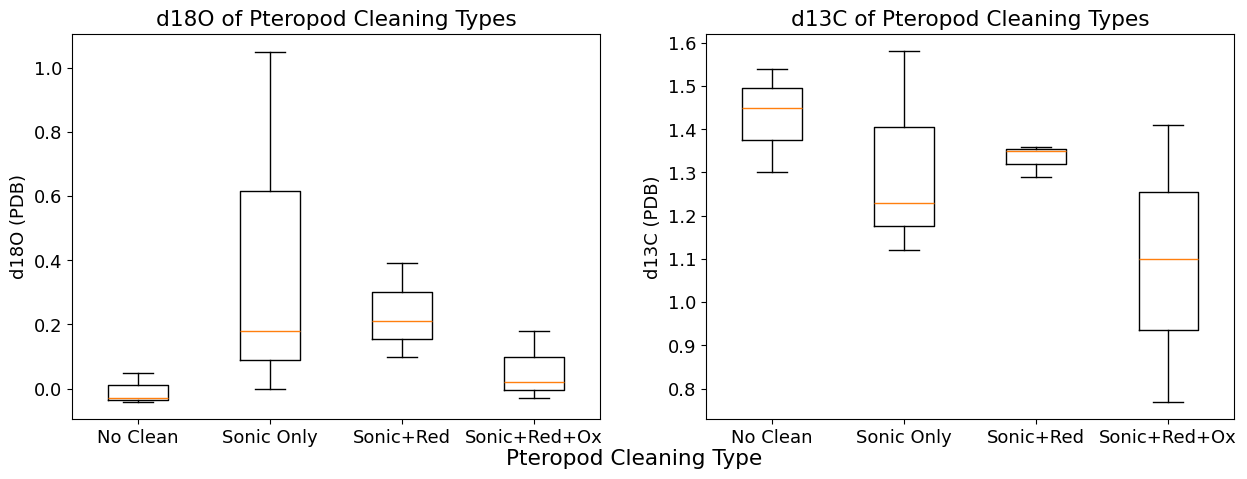

In [19]:
#graph 12: box plots of 18O and 13C vs cleaning types

fig, axes = plt.subplots(1,2,figsize = (15,5))

#combine data
o18data = nocleano, sonico, redsonico, oxredsonico
label = 'No Clean','Sonic Only','Sonic+Red','Sonic+Red+Ox'
c13data = nocleanc, sonicc, redsonicc, oxredsonicc

axes[0].boxplot(o18data, tick_labels = label)
axes[0].set_ylabel('d18O (PDB)')

axes[1].boxplot(c13data, tick_labels = label)
axes[1].set_ylabel('d13C (PDB)')

fig.supxlabel('Pteropod Cleaning Type')
axes[0].set_title('d18O of Pteropod Cleaning Types')
axes[1].set_title('d13C of Pteropod Cleaning Types')

<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_73907/2107426780.py:22: SyntaxWarning: invalid escape sequence '\d'
  axes[0].set_title('$\delta$$^{18}$O of Pteropod Cleaning Types')


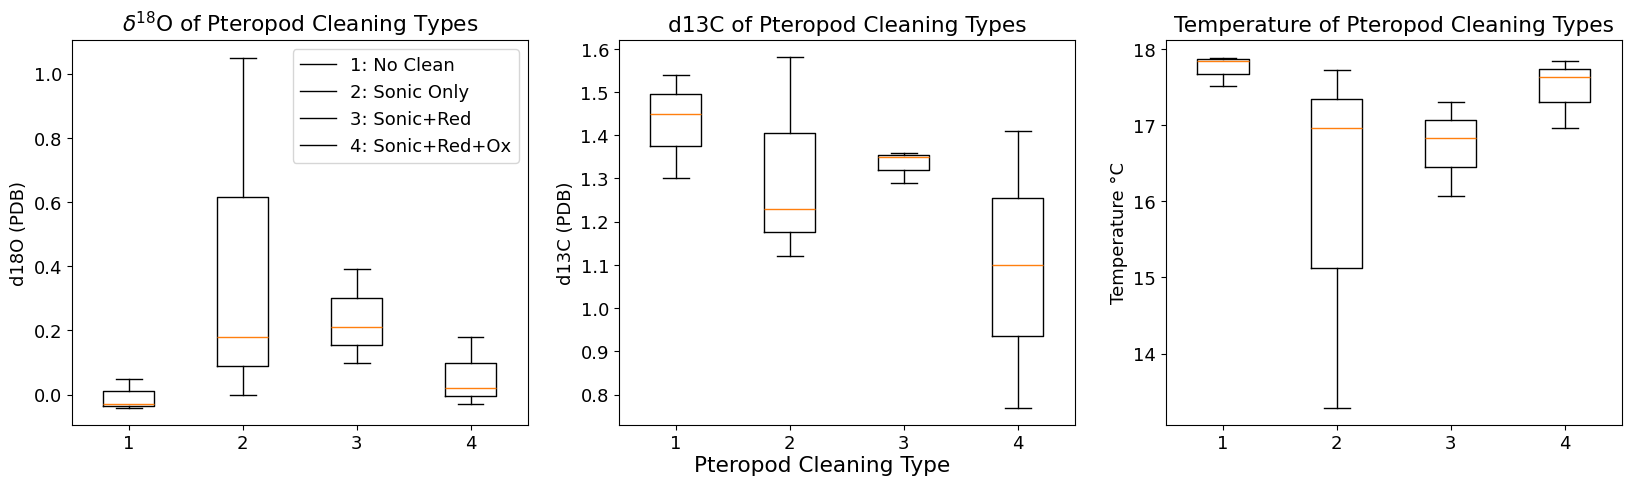

In [20]:
#graph 13: box plots for 18O, 13C and Temp vs cleaning types

fig, axes = plt.subplots(1,3,figsize = (20,5))

#combine data
o18data = nocleano, sonico, redsonico, oxredsonico
label = '1: No Clean','2: Sonic Only','3: Sonic+Red','4: Sonic+Red+Ox'
c13data = nocleanc, sonicc, redsonicc, oxredsonicc
tdata = nocleant, sonict, redsonict, oxredsonict 

axes[0].boxplot(o18data)
axes[0].set_ylabel('d18O (PDB)')

axes[1].boxplot(c13data)
axes[1].set_ylabel('d13C (PDB)')

axes[2].boxplot(tdata)
axes[2].set_ylabel('Temperature °C')

#titles
fig.supxlabel('Pteropod Cleaning Type')
axes[0].set_title('$\delta$$^{18}$O of Pteropod Cleaning Types')
axes[1].set_title('d13C of Pteropod Cleaning Types')
axes[2].set_title('Temperature of Pteropod Cleaning Types')

#legend
axes[0].legend(label)

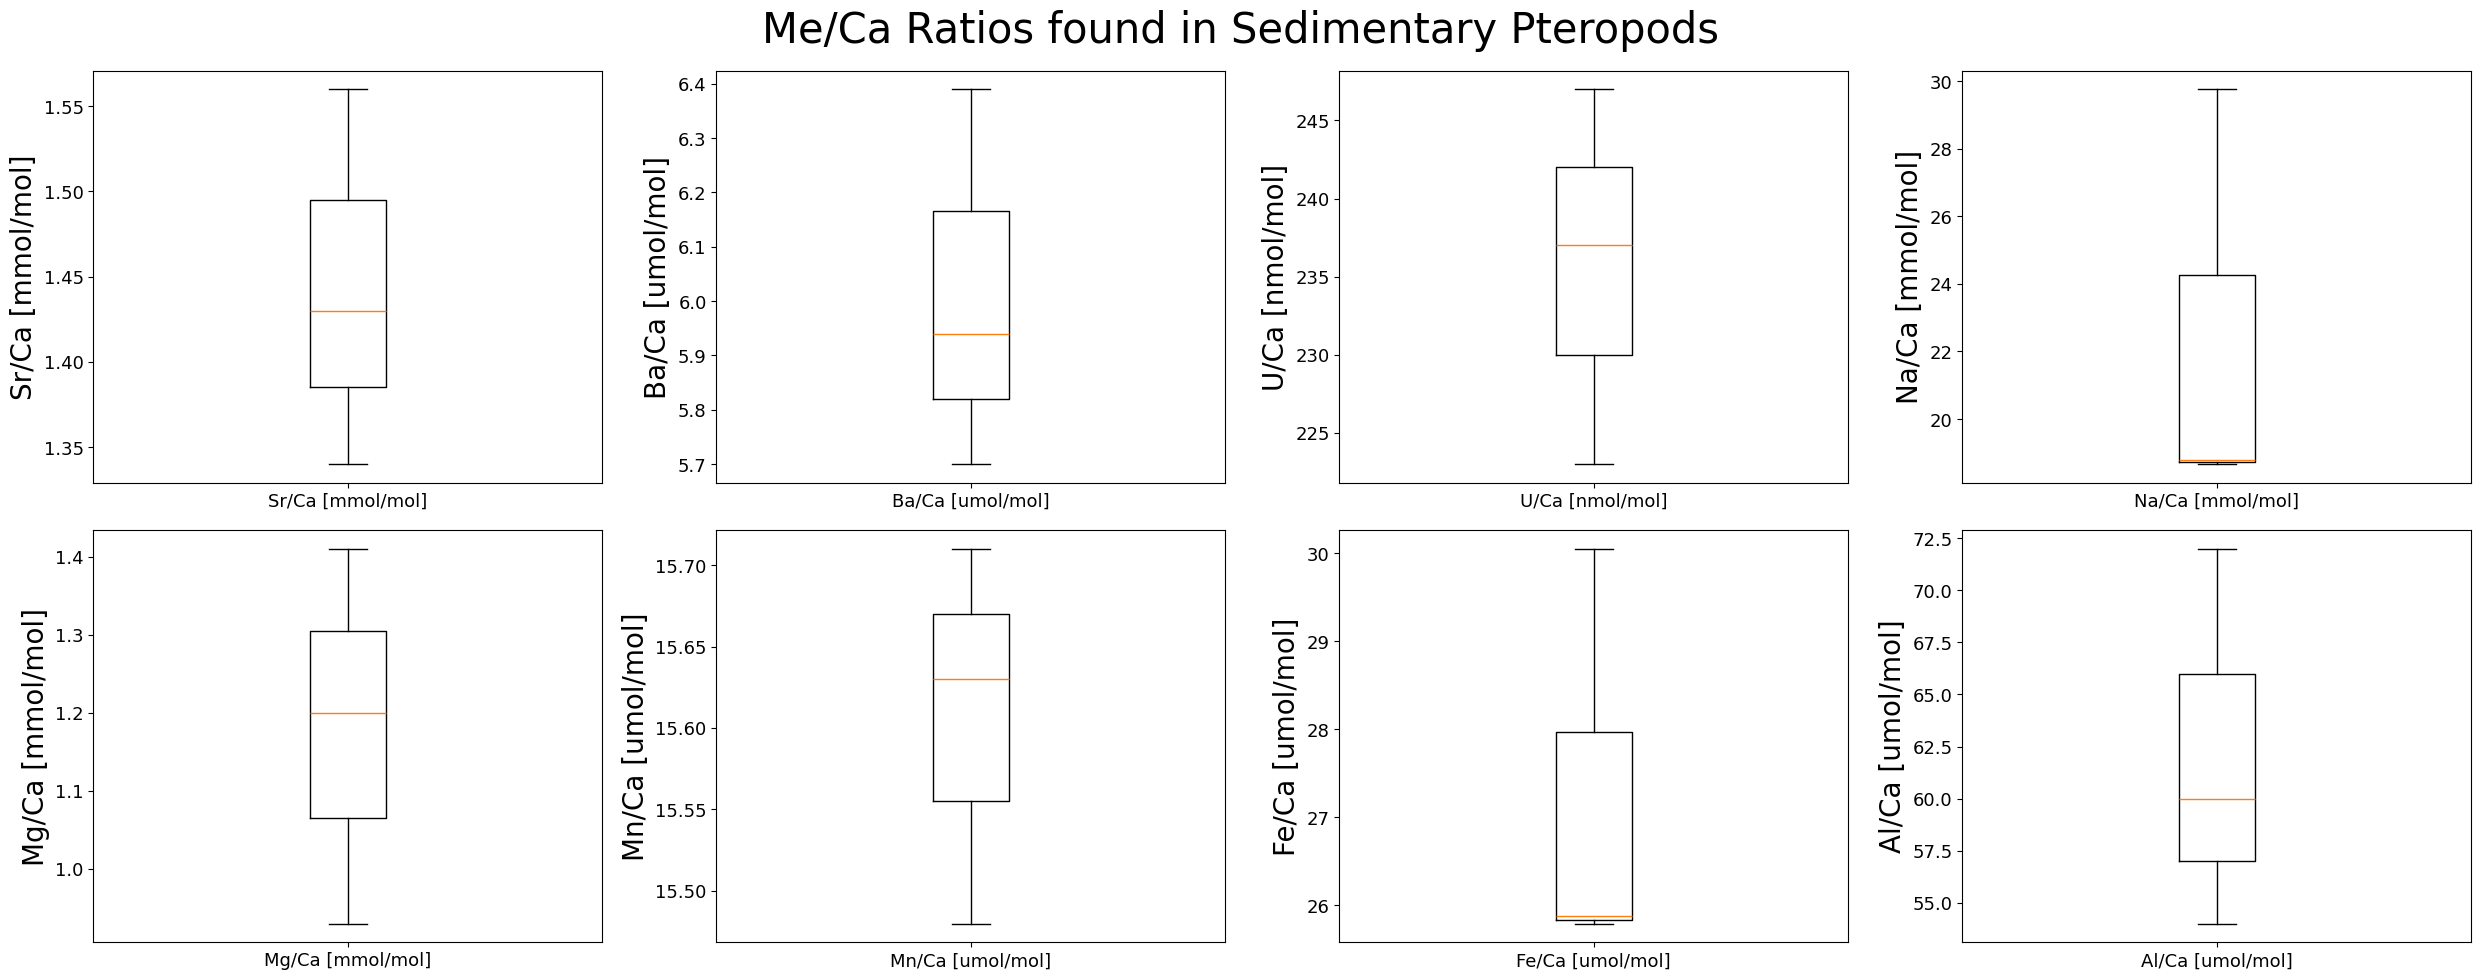

In [21]:
#Graph 14: water column pteropods vs Me/Ca ratios 

#labeling boxplots
Sr_Caname= {'Sr/Ca [mmol/mol]' :Srred}
Ba_Caname = { 'Ba/Ca [umol/mol]' : Bared}
U_Caname = {'U/Ca [nmol/mol]' : Ured}
Na_Caname = {'Na/Ca [mmol/mol]': Nared}
Mg_Caname ={'Mg/Ca [mmol/mol]' : Mgred} 
Mn_Caname = { 'Mn/Ca [umol/mol]' : Mnred}
Fe_Caname = {'Fe/Ca [umol/mol]' : Fered}
Al_Caname =  {'Al/Ca [umol/mol]' : Alred}


#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()


ax1.boxplot(Srred, tick_labels=Sr_Caname)

ax2.boxplot(Bared, tick_labels=Ba_Caname)

ax3.boxplot(Ured, tick_labels=U_Caname)

ax4.boxplot(Nared, tick_labels=Na_Caname)

ax5.boxplot(Mgred, tick_labels=Mg_Caname)

ax6.boxplot(Mnred, tick_labels=Mn_Caname)

ax7.boxplot(Fered, tick_labels=Fe_Caname) 

ax8.boxplot(Alred, tick_labels=Al_Caname)

#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')



#plot title
fig.suptitle('Me/Ca Ratios found in Sedimentary Pteropods', fontsize = 30)
# fig.supxlabel('Me/Ca Ratio', fontsize= 30)

#fixing spacing layout
fig.tight_layout()

#add grid lines
# ax1.grid()



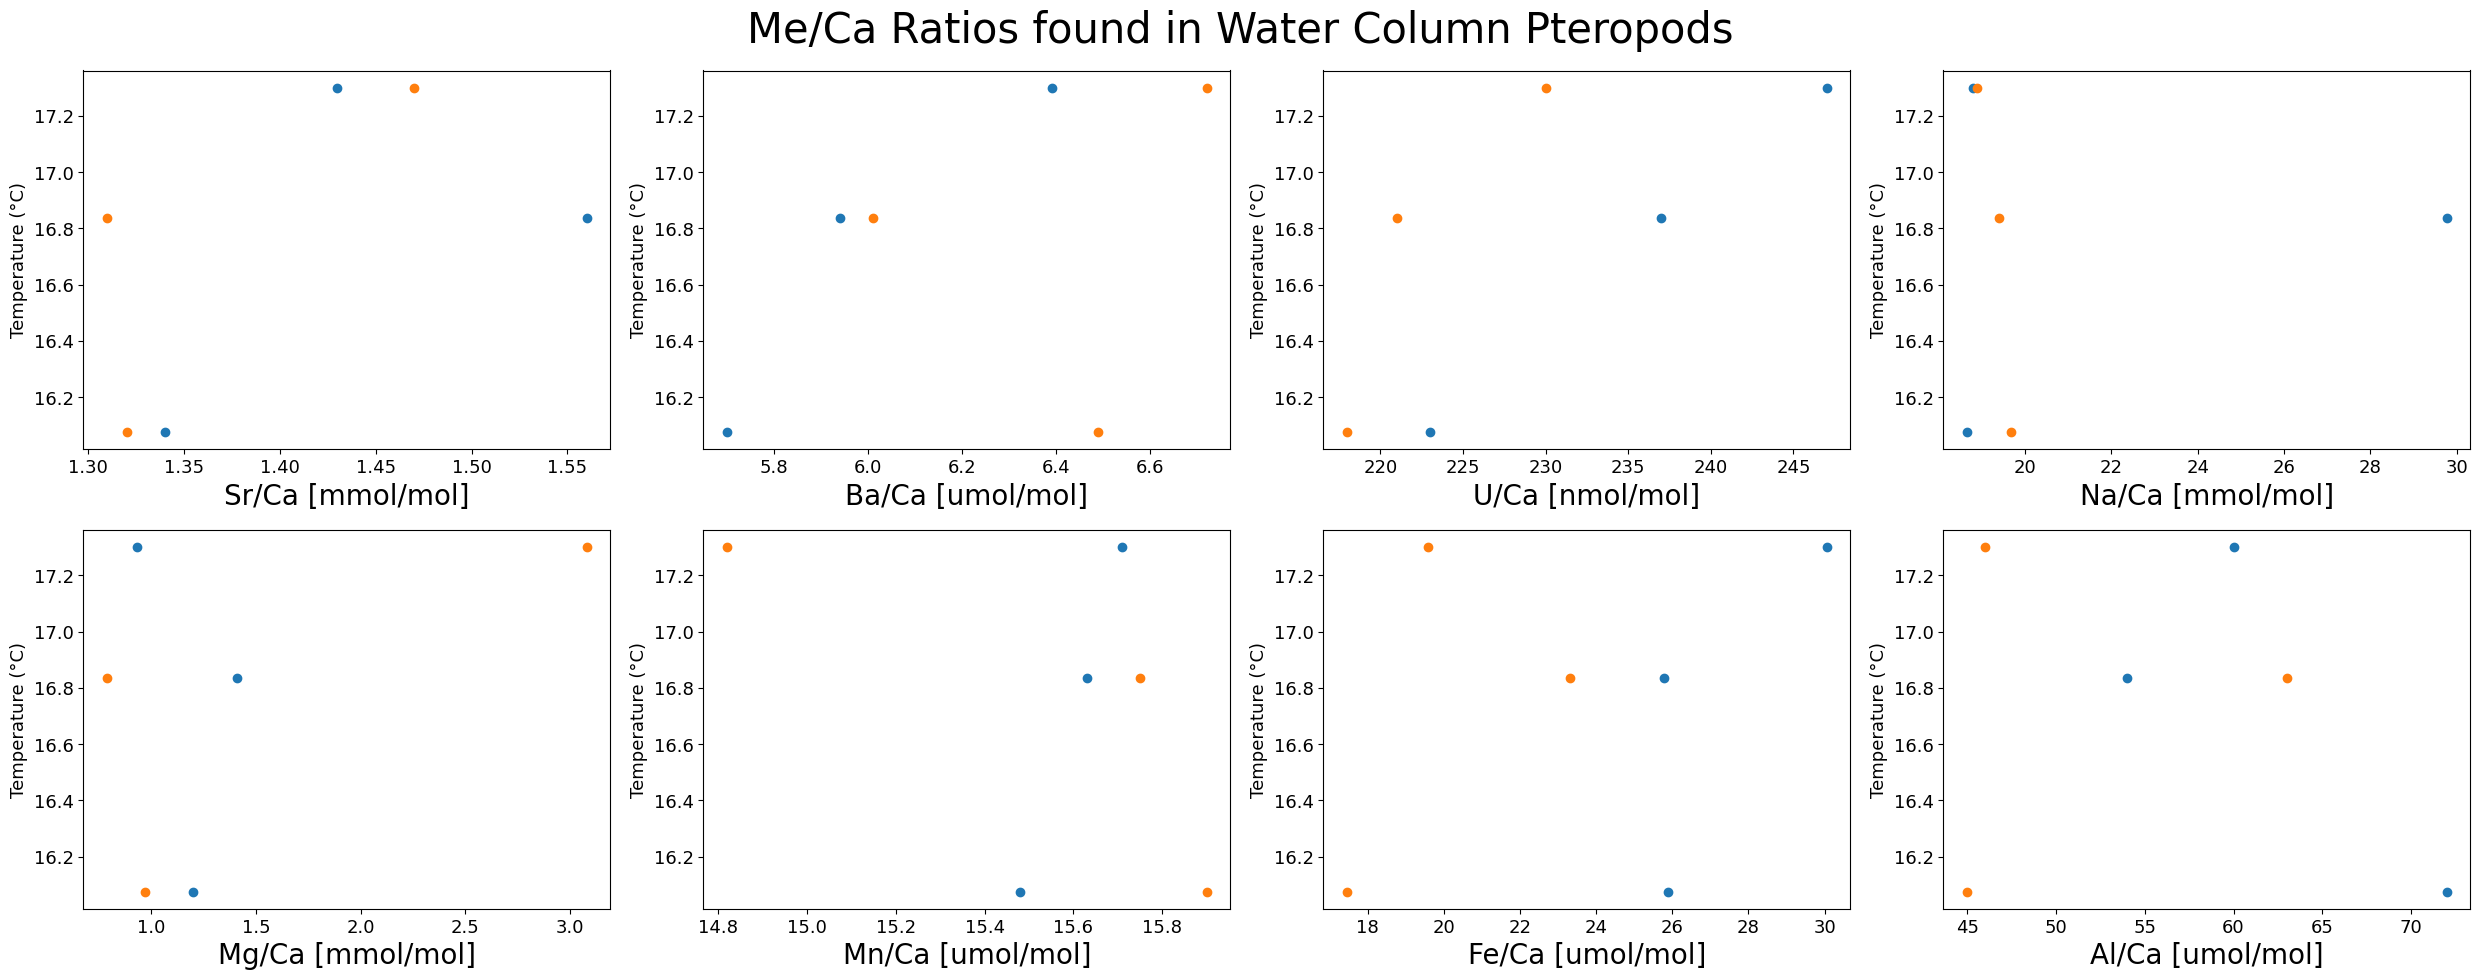

In [22]:
#Graph 15: water column pteropods Me/Ca ratios vs temperature

#labeling boxplots
Sr_Caname= {'Sr/Ca [mmol/mol]' :Srred}
Ba_Caname = { 'Ba/Ca [umol/mol]' : Bared}
U_Caname = {'U/Ca [nmol/mol]' : Ured}
Na_Caname = {'Na/Ca [mmol/mol]': Nared}
Mg_Caname ={'Mg/Ca [mmol/mol]' : Mgred} 
Mn_Caname = { 'Mn/Ca [umol/mol]' : Mnred}
Fe_Caname = {'Fe/Ca [umol/mol]' : Fered}
Al_Caname =  {'Al/Ca [umol/mol]' : Alred}


#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()

#redsonic 
ax1.scatter(Srred, redsonict)

ax2.scatter(Bared, redsonict)

ax3.scatter(Ured, redsonict)

ax4.scatter(Nared, redsonict)

ax5.scatter(Mgred, redsonict)

ax6.scatter(Mnred, redsonict)

ax7.scatter(Fered, redsonict) 

ax8.scatter(Alred, redsonict)

#oxredsonic

ax1.scatter(Srredox, redsonict)

ax2.scatter(Baredox, redsonict)

ax3.scatter(Uredox, redsonict)

ax4.scatter(Naredox, redsonict)

ax5.scatter(Mgredox, redsonict)

ax6.scatter(Mnredox, redsonict)

ax7.scatter(Feredox, redsonict) 

ax8.scatter(Alredox, redsonict)

#label axes
ax1.set_xlabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_ylabel('Temperature (°C)')

ax2.set_xlabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_ylabel('Temperature (°C)')

ax3.set_xlabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_ylabel('Temperature (°C)')

ax4.set_xlabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_ylabel('Temperature (°C)')

ax5.set_xlabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_ylabel('Temperature (°C)')

ax6.set_xlabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_ylabel('Temperature (°C)')

ax7.set_xlabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_ylabel('Temperature (°C)')

ax8.set_xlabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_ylabel('Temperature (°C)')



#plot title
fig.suptitle('Me/Ca Ratios found in Water Column Pteropods', fontsize = 30)
# fig.supxlabel('Me/Ca Ratio', fontsize= 30)

#fixing spacing layout
fig.tight_layout()

#add grid lines
# ax1.grid()



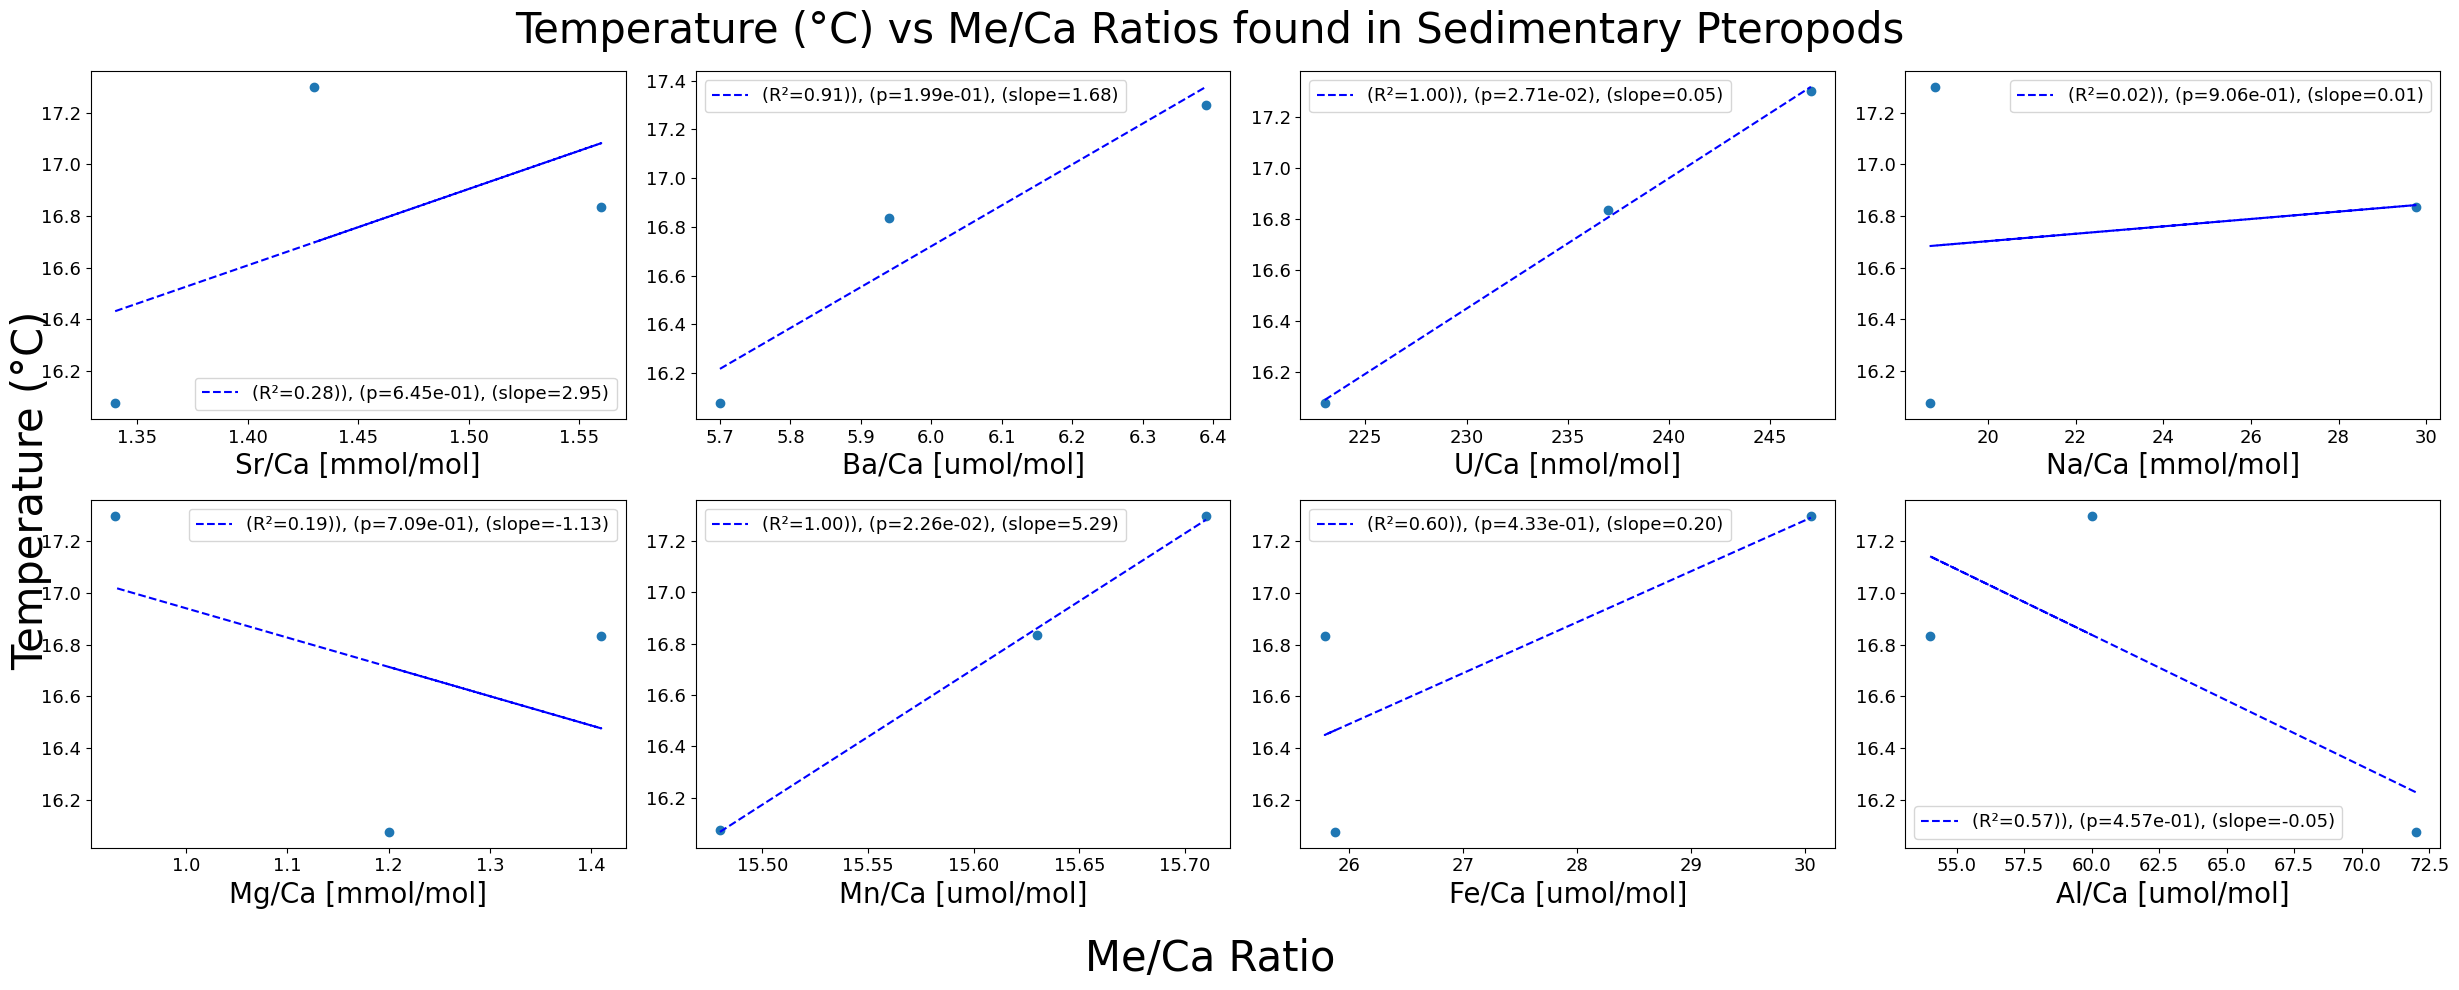

In [24]:
#Graph 16:  linear regression of red+sonic pteropods Me/Ca ratios vs temperature

#labeling boxplots
Sr_Caname= {'Sr/Ca [mmol/mol]' :Srred}
Ba_Caname = { 'Ba/Ca [umol/mol]' : Bared}
U_Caname = {'U/Ca [nmol/mol]' : Ured}
Na_Caname = {'Na/Ca [mmol/mol]': Nared}
Mg_Caname ={'Mg/Ca [mmol/mol]' : Mgred} 
Mn_Caname = { 'Mn/Ca [umol/mol]' : Mnred}
Fe_Caname = {'Fe/Ca [umol/mol]' : Fered}
Al_Caname =  {'Al/Ca [umol/mol]' : Alred}


#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()

#redsonic 
ax1.scatter(Srred, redsonict)

ax2.scatter(Bared, redsonict)

ax3.scatter(Ured, redsonict)

ax4.scatter(Nared, redsonict)

ax5.scatter(Mgred, redsonict)

ax6.scatter(Mnred, redsonict)

ax7.scatter(Fered, redsonict) 

ax8.scatter(Alred, redsonict)

# calulate linear regression 
sloperedSr, interceptredSr, r_valueredSr, p_valueredSr, std_errredSr = linregress(Srred, redsonict)
regression_yredSr = sloperedSr * Srred + interceptredSr
r_squaredredSr = r_valueredSr**2

sloperedBa, interceptredBa, r_valueredBa, p_valueredBa, std_errredBa = linregress(Bared, redsonict)
regression_yredBa = sloperedBa * Bared + interceptredBa
r_squaredredBa = r_valueredBa**2

sloperedU, interceptredU, r_valueredU, p_valueredU, std_errredU = linregress(Ured, redsonict)
regression_yredU = sloperedU * Ured + interceptredU
r_squaredredU = r_valueredU**2

sloperedNa, interceptredNa, r_valueredNa, p_valueredNa, std_errredNa = linregress(Nared, redsonict)
regression_yredNa = sloperedNa * Nared + interceptredNa
r_squaredredNa = r_valueredNa**2

sloperedMg, interceptredMg, r_valueredMg, p_valueredMg, std_errredMg = linregress(Mgred, redsonict)
regression_yredMg = sloperedMg * Mgred + interceptredMg
r_squaredredMg = r_valueredMg**2

sloperedMn, interceptredMn, r_valueredMn, p_valueredMn, std_errredMn = linregress(Mnred, redsonict)
regression_yredMn = sloperedMn * Mnred + interceptredMn
r_squaredredMn = r_valueredMn**2

sloperedFe, interceptredFe, r_valueredFe, p_valueredFe, std_errredFe = linregress(Fered, redsonict)
regression_yredFe = sloperedFe * Fered + interceptredFe
r_squaredredFe = r_valueredFe**2

sloperedAl, interceptredAl, r_valueredAl, p_valueredAl, std_errredAl = linregress(Alred, redsonict)
regression_yredAl = sloperedAl * Alred + interceptredAl
r_squaredredAl = r_valueredAl**2

#plot linear regression 
ax1.plot(Srred, regression_yredSr, label=f'(R²={r_squaredredSr:.2f})), (p={p_valueredSr:.2e}), (slope={sloperedSr:.2f})', color='b', linestyle='--')

ax2.plot(Bared, regression_yredBa, label=f'(R²={r_squaredredBa:.2f})), (p={p_valueredBa:.2e}), (slope={sloperedBa:.2f})', color='b', linestyle='--')

ax3.plot(Ured, regression_yredU, label=f'(R²={r_squaredredU:.2f})), (p={p_valueredU:.2e}), (slope={sloperedU:.2f})', color='b', linestyle='--')

ax4.plot(Nared, regression_yredNa, label=f'(R²={r_squaredredNa:.2f})), (p={p_valueredNa:.2e}), (slope={sloperedNa:.2f})', color='b', linestyle='--')

ax5.plot(Mgred, regression_yredMg, label=f'(R²={r_squaredredMg:.2f})), (p={p_valueredMg:.2e}), (slope={sloperedMg:.2f})', color='b', linestyle='--')

ax6.plot(Mnred, regression_yredMn, label=f'(R²={r_squaredredMn:.2f})), (p={p_valueredMn:.2e}), (slope={sloperedMn:.2f})', color='b', linestyle='--')

ax7.plot(Fered, regression_yredFe, label=f'(R²={r_squaredredFe:.2f})), (p={p_valueredFe:.2e}), (slope={sloperedFe:.2f})', color='b', linestyle='--')

ax8.plot(Alred, regression_yredAl, label=f'(R²={r_squaredredAl:.2f})), (p={p_valueredAl:.2e}), (slope={sloperedAl:.2f})', color='b', linestyle='--')



#label axes
ax1.set_xlabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_ylabel('')

ax2.set_xlabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_ylabel('')

ax3.set_xlabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_ylabel('')

ax4.set_xlabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_ylabel('')

ax5.set_xlabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_ylabel('')

ax6.set_xlabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_ylabel('')

ax7.set_xlabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_ylabel('')

ax8.set_xlabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_ylabel('')



#plot title
fig.suptitle('Temperature (°C) vs Me/Ca Ratios found in Sedimentary Pteropods', fontsize = 30)
fig.supylabel('Temperature (°C)', fontsize= 30)
fig.supxlabel ('Me/Ca Ratio', fontsize = 30)
#fixing spacing layout
fig.tight_layout()

#add legend
ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()
ax5.legend()
ax6.legend()
ax7.legend()
ax8.legend()



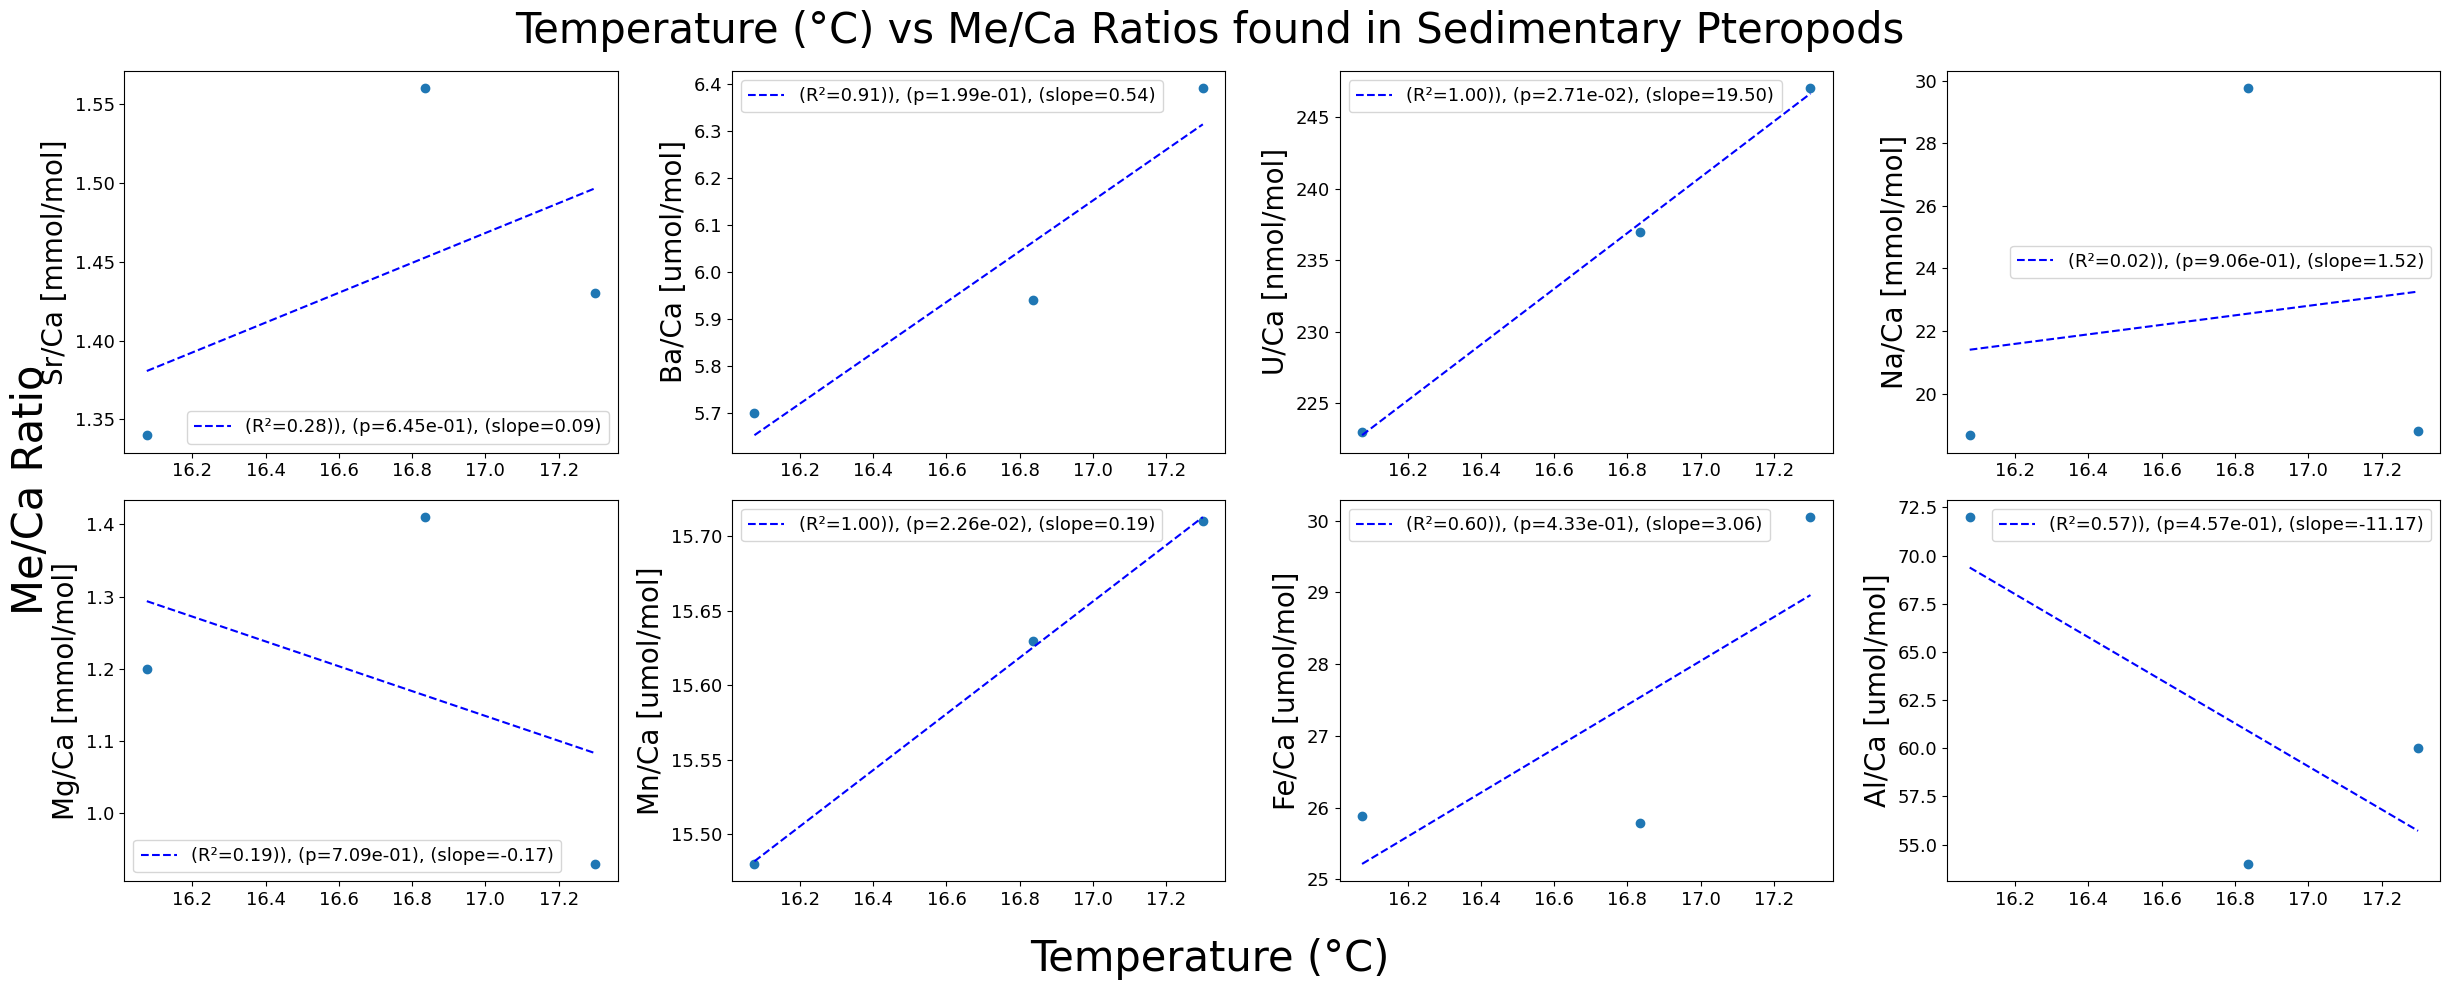

In [26]:
#Graph 17: linear regression of temperature vs red+sonic pteropods Me/Ca ratios

#labeling boxplots
Sr_Caname= {'Sr/Ca [mmol/mol]' :Srred}
Ba_Caname = { 'Ba/Ca [umol/mol]' : Bared}
U_Caname = {'U/Ca [nmol/mol]' : Ured}
Na_Caname = {'Na/Ca [mmol/mol]': Nared}
Mg_Caname ={'Mg/Ca [mmol/mol]' : Mgred} 
Mn_Caname = { 'Mn/Ca [umol/mol]' : Mnred}
Fe_Caname = {'Fe/Ca [umol/mol]' : Fered}
Al_Caname =  {'Al/Ca [umol/mol]' : Alred}


#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()

#redsonic 
ax1.scatter(redsonict, Srred)

ax2.scatter(redsonict, Bared)

ax3.scatter(redsonict, Ured)

ax4.scatter(redsonict, Nared)

ax5.scatter(redsonict, Mgred)

ax6.scatter(redsonict, Mnred)

ax7.scatter(redsonict, Fered) 

ax8.scatter(redsonict, Alred)

# calulate linear regression 
sloperedSr, interceptredSr, r_valueredSr, p_valueredSr, std_errredSr = linregress( redsonict, Srred)
regression_yredSr = sloperedSr * redsonict + interceptredSr
r_squaredredSr = r_valueredSr**2

sloperedBa, interceptredBa, r_valueredBa, p_valueredBa, std_errredBa = linregress(redsonict, Bared)
regression_yredBa = sloperedBa * redsonict + interceptredBa
r_squaredredBa = r_valueredBa**2

sloperedU, interceptredU, r_valueredU, p_valueredU, std_errredU = linregress(redsonict, Ured)
regression_yredU = sloperedU * redsonict + interceptredU
r_squaredredU = r_valueredU**2

sloperedNa, interceptredNa, r_valueredNa, p_valueredNa, std_errredNa = linregress(redsonict, Nared)
regression_yredNa = sloperedNa * redsonict + interceptredNa
r_squaredredNa = r_valueredNa**2

sloperedMg, interceptredMg, r_valueredMg, p_valueredMg, std_errredMg = linregress(redsonict, Mgred)
regression_yredMg = sloperedMg * redsonict + interceptredMg
r_squaredredMg = r_valueredMg**2

sloperedMn, interceptredMn, r_valueredMn, p_valueredMn, std_errredMn = linregress(redsonict, Mnred)
regression_yredMn = sloperedMn * redsonict + interceptredMn
r_squaredredMn = r_valueredMn**2

sloperedFe, interceptredFe, r_valueredFe, p_valueredFe, std_errredFe = linregress(redsonict, Fered)
regression_yredFe = sloperedFe * redsonict + interceptredFe
r_squaredredFe = r_valueredFe**2

sloperedAl, interceptredAl, r_valueredAl, p_valueredAl, std_errredAl = linregress(redsonict, Alred)
regression_yredAl = sloperedAl * redsonict+ interceptredAl
r_squaredredAl = r_valueredAl**2

#plot linear regression 
ax1.plot(redsonict, regression_yredSr, label=f'(R²={r_squaredredSr:.2f})), (p={p_valueredSr:.2e}), (slope={sloperedSr:.2f})', color='b', linestyle='--')

ax2.plot(redsonict, regression_yredBa, label=f'(R²={r_squaredredBa:.2f})), (p={p_valueredBa:.2e}), (slope={sloperedBa:.2f})', color='b', linestyle='--')

ax3.plot(redsonict, regression_yredU, label=f'(R²={r_squaredredU:.2f})), (p={p_valueredU:.2e}), (slope={sloperedU:.2f})', color='b', linestyle='--')

ax4.plot(redsonict, regression_yredNa, label=f'(R²={r_squaredredNa:.2f})), (p={p_valueredNa:.2e}), (slope={sloperedNa:.2f})', color='b', linestyle='--')

ax5.plot(redsonict, regression_yredMg, label=f'(R²={r_squaredredMg:.2f})), (p={p_valueredMg:.2e}), (slope={sloperedMg:.2f})', color='b', linestyle='--')

ax6.plot(redsonict, regression_yredMn, label=f'(R²={r_squaredredMn:.2f})), (p={p_valueredMn:.2e}), (slope={sloperedMn:.2f})', color='b', linestyle='--')

ax7.plot(redsonict, regression_yredFe, label=f'(R²={r_squaredredFe:.2f})), (p={p_valueredFe:.2e}), (slope={sloperedFe:.2f})', color='b', linestyle='--')

ax8.plot(redsonict, regression_yredAl, label=f'(R²={r_squaredredAl:.2f})), (p={p_valueredAl:.2e}), (slope={sloperedAl:.2f})', color='b', linestyle='--')



#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')



#plot title
fig.suptitle('Temperature (°C) vs Me/Ca Ratios found in Sedimentary Pteropods', fontsize = 30)
fig.supxlabel('Temperature (°C)', fontsize= 30)
fig.supylabel ('Me/Ca Ratio', fontsize = 30)
#fixing spacing layout
fig.tight_layout()

#add legend
ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()
ax5.legend()
ax6.legend()
ax7.legend()
ax8.legend()



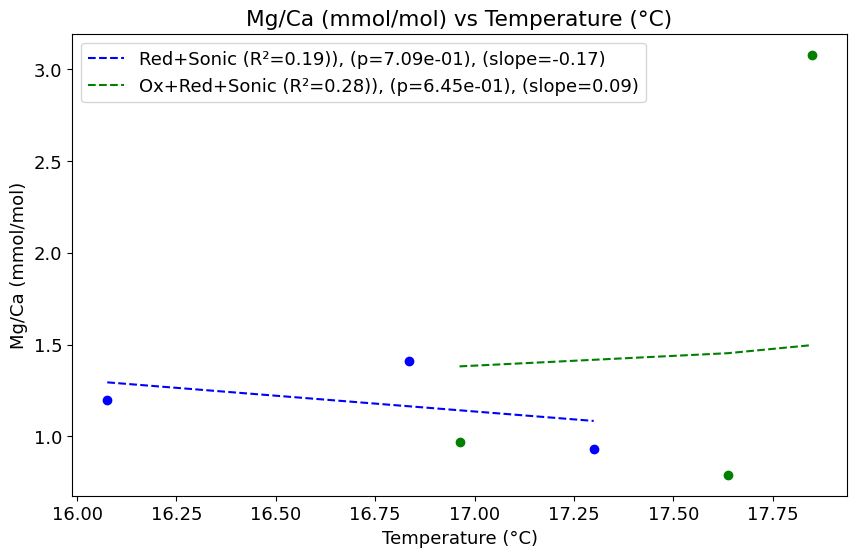

In [27]:
# graph 18: plot Mg/Ca for red+sonic and ox+red+sonic pteropods vs temp

plt.figure(figsize = (10,6))

plt.scatter(redsonict, Mgred, color = 'b')
plt.scatter(oxredsonict, Mgredox, color = 'g')

sloperedMg, interceptredMg, r_valueredMg, p_valueredMg, std_errredMg = linregress(redsonict, Mgred)
regression_yredMg = sloperedMg * redsonict + interceptredMg
r_squaredredMg = r_valueredMg**2

sloperedoxMg, interceptredoxMg, r_valueredoxMg, p_valueredoxMg, std_errredoxMg = linregress(oxredsonict, Mgredox)
regression_yredoxMg = sloperedoxMg * oxredsonict+ interceptredoxMg
r_squaredredoxMg = r_valueredoxMg**2

#plot linear regression 
plt.plot(redsonict, regression_yredMg, label=f'Red+Sonic (R²={r_squaredredMg:.2f})), (p={p_valueredMg:.2e}), (slope={sloperedMg:.2f})', color='b', linestyle='--')

plt.plot(oxredsonict, regression_yredSr, label=f'Ox+Red+Sonic (R²={r_squaredredSr:.2f})), (p={p_valueredSr:.2e}), (slope={sloperedSr:.2f})', color='g', linestyle='--')

plt.xlabel('Temperature (°C)')
plt.ylabel('Mg/Ca (mmol/mol)')
plt.title('Mg/Ca (mmol/mol) vs Temperature (°C)')

plt.legend()



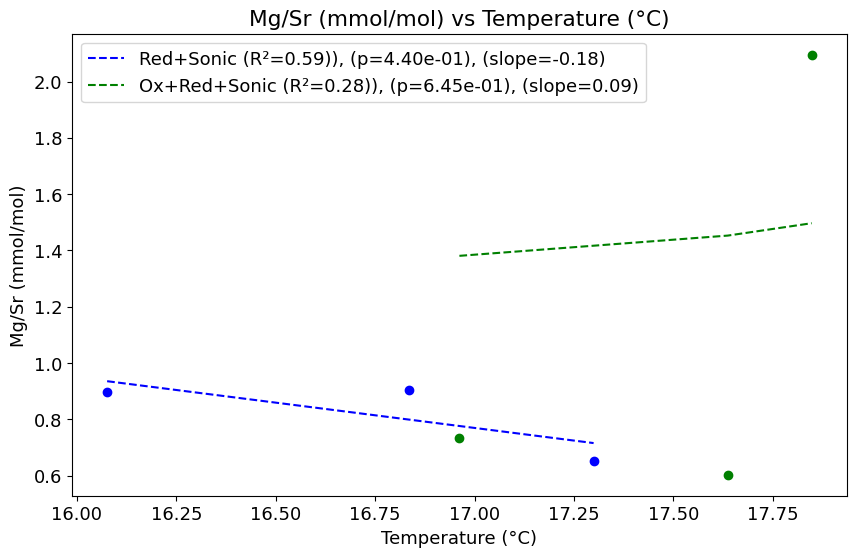

In [30]:
#graph 19: Mg/Ca/Sr/Ca for red+sonic and ox+red+sonic pteropods vs temp

plt.figure(figsize = (10,6))

MgSrred = Mgred/Srred
MgSrredox = Mgredox/Srredox

plt.scatter(redsonict, MgSrred, color = 'b')
plt.scatter(oxredsonict, MgSrredox, color = 'g')

sloperedMg, interceptredMg, r_valueredMg, p_valueredMg, std_errredMg = linregress(redsonict, MgSrred)
regression_yredMg = sloperedMg * redsonict + interceptredMg
r_squaredredMg = r_valueredMg**2

sloperedoxMg, interceptredoxMg, r_valueredoxMg, p_valueredoxMg, std_errredoxMg = linregress(oxredsonict, MgSrredox)
regression_yredoxMg = sloperedoxMg * oxredsonict+ interceptredoxMg
r_squaredredoxMg = r_valueredoxMg**2

#plot linear regression 
plt.plot(redsonict, regression_yredMg, label=f'Red+Sonic (R²={r_squaredredMg:.2f})), (p={p_valueredMg:.2e}), (slope={sloperedMg:.2f})', color='b', linestyle='--')

plt.plot(oxredsonict, regression_yredSr, label=f'Ox+Red+Sonic (R²={r_squaredredSr:.2f})), (p={p_valueredSr:.2e}), (slope={sloperedSr:.2f})', color='g', linestyle='--')

plt.xlabel('Temperature (°C)')
plt.ylabel('Mg/Sr (mmol/mol)')
plt.title('Mg/Sr (mmol/mol) vs Temperature (°C)')

plt.legend()



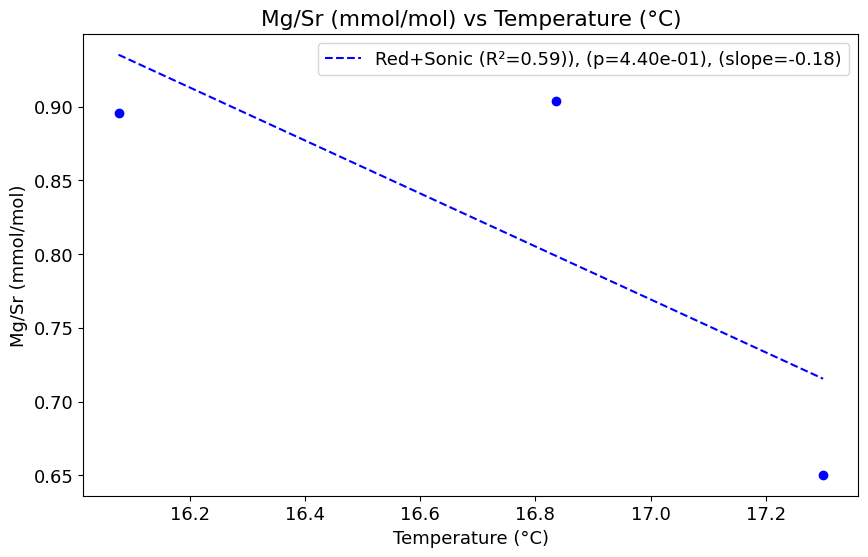

In [32]:
#graph 20: Mg/Ca/Sr/Ca for red+sonic pteropodsvs temp

plt.figure(figsize = (10,6))

MgSrred = Mgred/Srred


plt.scatter(redsonict, MgSrred, color = 'b')


sloperedMg, interceptredMg, r_valueredMg, p_valueredMg, std_errredMg = linregress(redsonict, MgSrred)
regression_yredMg = sloperedMg * redsonict + interceptredMg
r_squaredredMg = r_valueredMg**2


#plot linear regression 
plt.plot(redsonict, regression_yredMg, label=f'Red+Sonic (R²={r_squaredredMg:.2f})), (p={p_valueredMg:.2e}), (slope={sloperedMg:.2f})', color='b', linestyle='--')

plt.xlabel('Temperature (°C)')
plt.ylabel('Mg/Sr (mmol/mol)')
plt.title('Mg/Sr (mmol/mol) vs Temperature (°C)')

plt.legend()



<>:104: SyntaxWarning: invalid escape sequence '\d'
<>:105: SyntaxWarning: invalid escape sequence '\d'
<>:104: SyntaxWarning: invalid escape sequence '\d'
<>:105: SyntaxWarning: invalid escape sequence '\d'
/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_73907/2753779192.py:104: SyntaxWarning: invalid escape sequence '\d'
  fig.suptitle('$\delta$$^{18}$O (PDB) vs Me/Ca Ratios found in Sedimentary Pteropods', fontsize = 30)
/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_73907/2753779192.py:105: SyntaxWarning: invalid escape sequence '\d'
  fig.supxlabel('$\delta$$^{18}$O (PDB)', fontsize= 30)


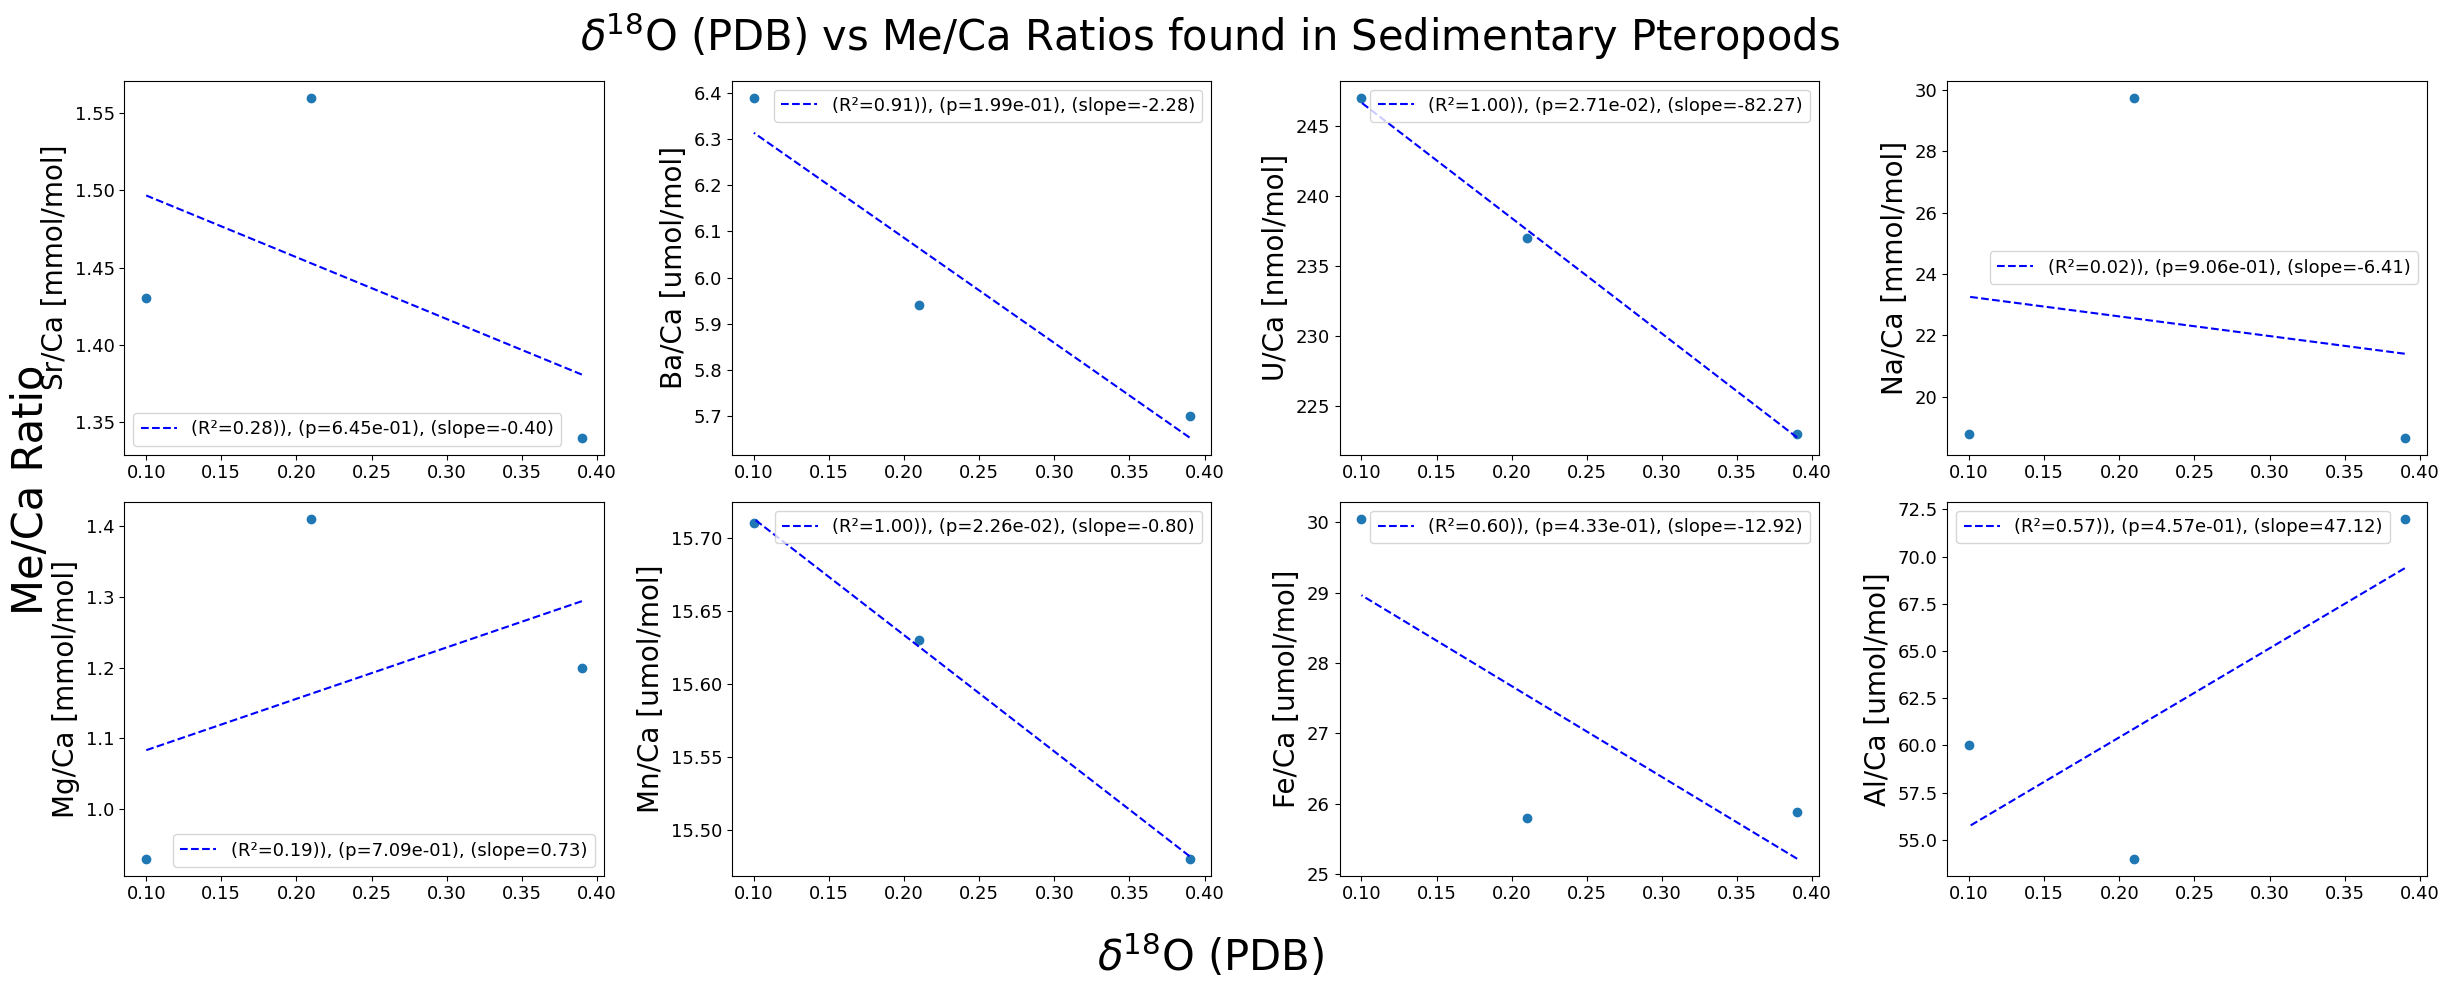

In [34]:
#graph 21: 18O vs me/ca ratios 

#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()

#redsonic 
ax1.scatter(redsonico, Srred)

ax2.scatter(redsonico, Bared)

ax3.scatter(redsonico, Ured)

ax4.scatter(redsonico, Nared)

ax5.scatter(redsonico, Mgred)

ax6.scatter(redsonico, Mnred)

ax7.scatter(redsonico, Fered) 

ax8.scatter(redsonico, Alred)

# calulate linear regression 
sloperedSr, interceptredSr, r_valueredSr, p_valueredSr, std_errredSr = linregress( redsonico, Srred)
regression_yredSr = sloperedSr * redsonico + interceptredSr
r_squaredredSr = r_valueredSr**2

sloperedBa, interceptredBa, r_valueredBa, p_valueredBa, std_errredBa = linregress(redsonico, Bared)
regression_yredBa = sloperedBa * redsonico + interceptredBa
r_squaredredBa = r_valueredBa**2

sloperedU, interceptredU, r_valueredU, p_valueredU, std_errredU = linregress(redsonico, Ured)
regression_yredU = sloperedU * redsonico + interceptredU
r_squaredredU = r_valueredU**2

sloperedNa, interceptredNa, r_valueredNa, p_valueredNa, std_errredNa = linregress(redsonico, Nared)
regression_yredNa = sloperedNa * redsonico + interceptredNa
r_squaredredNa = r_valueredNa**2

sloperedMg, interceptredMg, r_valueredMg, p_valueredMg, std_errredMg = linregress(redsonico, Mgred)
regression_yredMg = sloperedMg * redsonico + interceptredMg
r_squaredredMg = r_valueredMg**2

sloperedMn, interceptredMn, r_valueredMn, p_valueredMn, std_errredMn = linregress(redsonico, Mnred)
regression_yredMn = sloperedMn * redsonico + interceptredMn
r_squaredredMn = r_valueredMn**2

sloperedFe, interceptredFe, r_valueredFe, p_valueredFe, std_errredFe = linregress(redsonico, Fered)
regression_yredFe = sloperedFe * redsonico + interceptredFe
r_squaredredFe = r_valueredFe**2

sloperedAl, interceptredAl, r_valueredAl, p_valueredAl, std_errredAl = linregress(redsonico, Alred)
regression_yredAl = sloperedAl * redsonico+ interceptredAl
r_squaredredAl = r_valueredAl**2

#plot linear regression 
ax1.plot(redsonico, regression_yredSr, label=f'(R²={r_squaredredSr:.2f})), (p={p_valueredSr:.2e}), (slope={sloperedSr:.2f})', color='b', linestyle='--')

ax2.plot(redsonico, regression_yredBa, label=f'(R²={r_squaredredBa:.2f})), (p={p_valueredBa:.2e}), (slope={sloperedBa:.2f})', color='b', linestyle='--')

ax3.plot(redsonico, regression_yredU, label=f'(R²={r_squaredredU:.2f})), (p={p_valueredU:.2e}), (slope={sloperedU:.2f})', color='b', linestyle='--')

ax4.plot(redsonico, regression_yredNa, label=f'(R²={r_squaredredNa:.2f})), (p={p_valueredNa:.2e}), (slope={sloperedNa:.2f})', color='b', linestyle='--')

ax5.plot(redsonico, regression_yredMg, label=f'(R²={r_squaredredMg:.2f})), (p={p_valueredMg:.2e}), (slope={sloperedMg:.2f})', color='b', linestyle='--')

ax6.plot(redsonico, regression_yredMn, label=f'(R²={r_squaredredMn:.2f})), (p={p_valueredMn:.2e}), (slope={sloperedMn:.2f})', color='b', linestyle='--')

ax7.plot(redsonico, regression_yredFe, label=f'(R²={r_squaredredFe:.2f})), (p={p_valueredFe:.2e}), (slope={sloperedFe:.2f})', color='b', linestyle='--')

ax8.plot(redsonico, regression_yredAl, label=f'(R²={r_squaredredAl:.2f})), (p={p_valueredAl:.2e}), (slope={sloperedAl:.2f})', color='b', linestyle='--')



#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')



#plot title
fig.suptitle('$\delta$$^{18}$O (PDB) vs Me/Ca Ratios found in Sedimentary Pteropods', fontsize = 30)
fig.supxlabel('$\delta$$^{18}$O (PDB)', fontsize= 30)
fig.supylabel ('Me/Ca Ratio', fontsize = 30)
#fixing spacing layout
fig.tight_layout()

#add legend
ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()
ax5.legend()
ax6.legend()
ax7.legend()
ax8.legend()



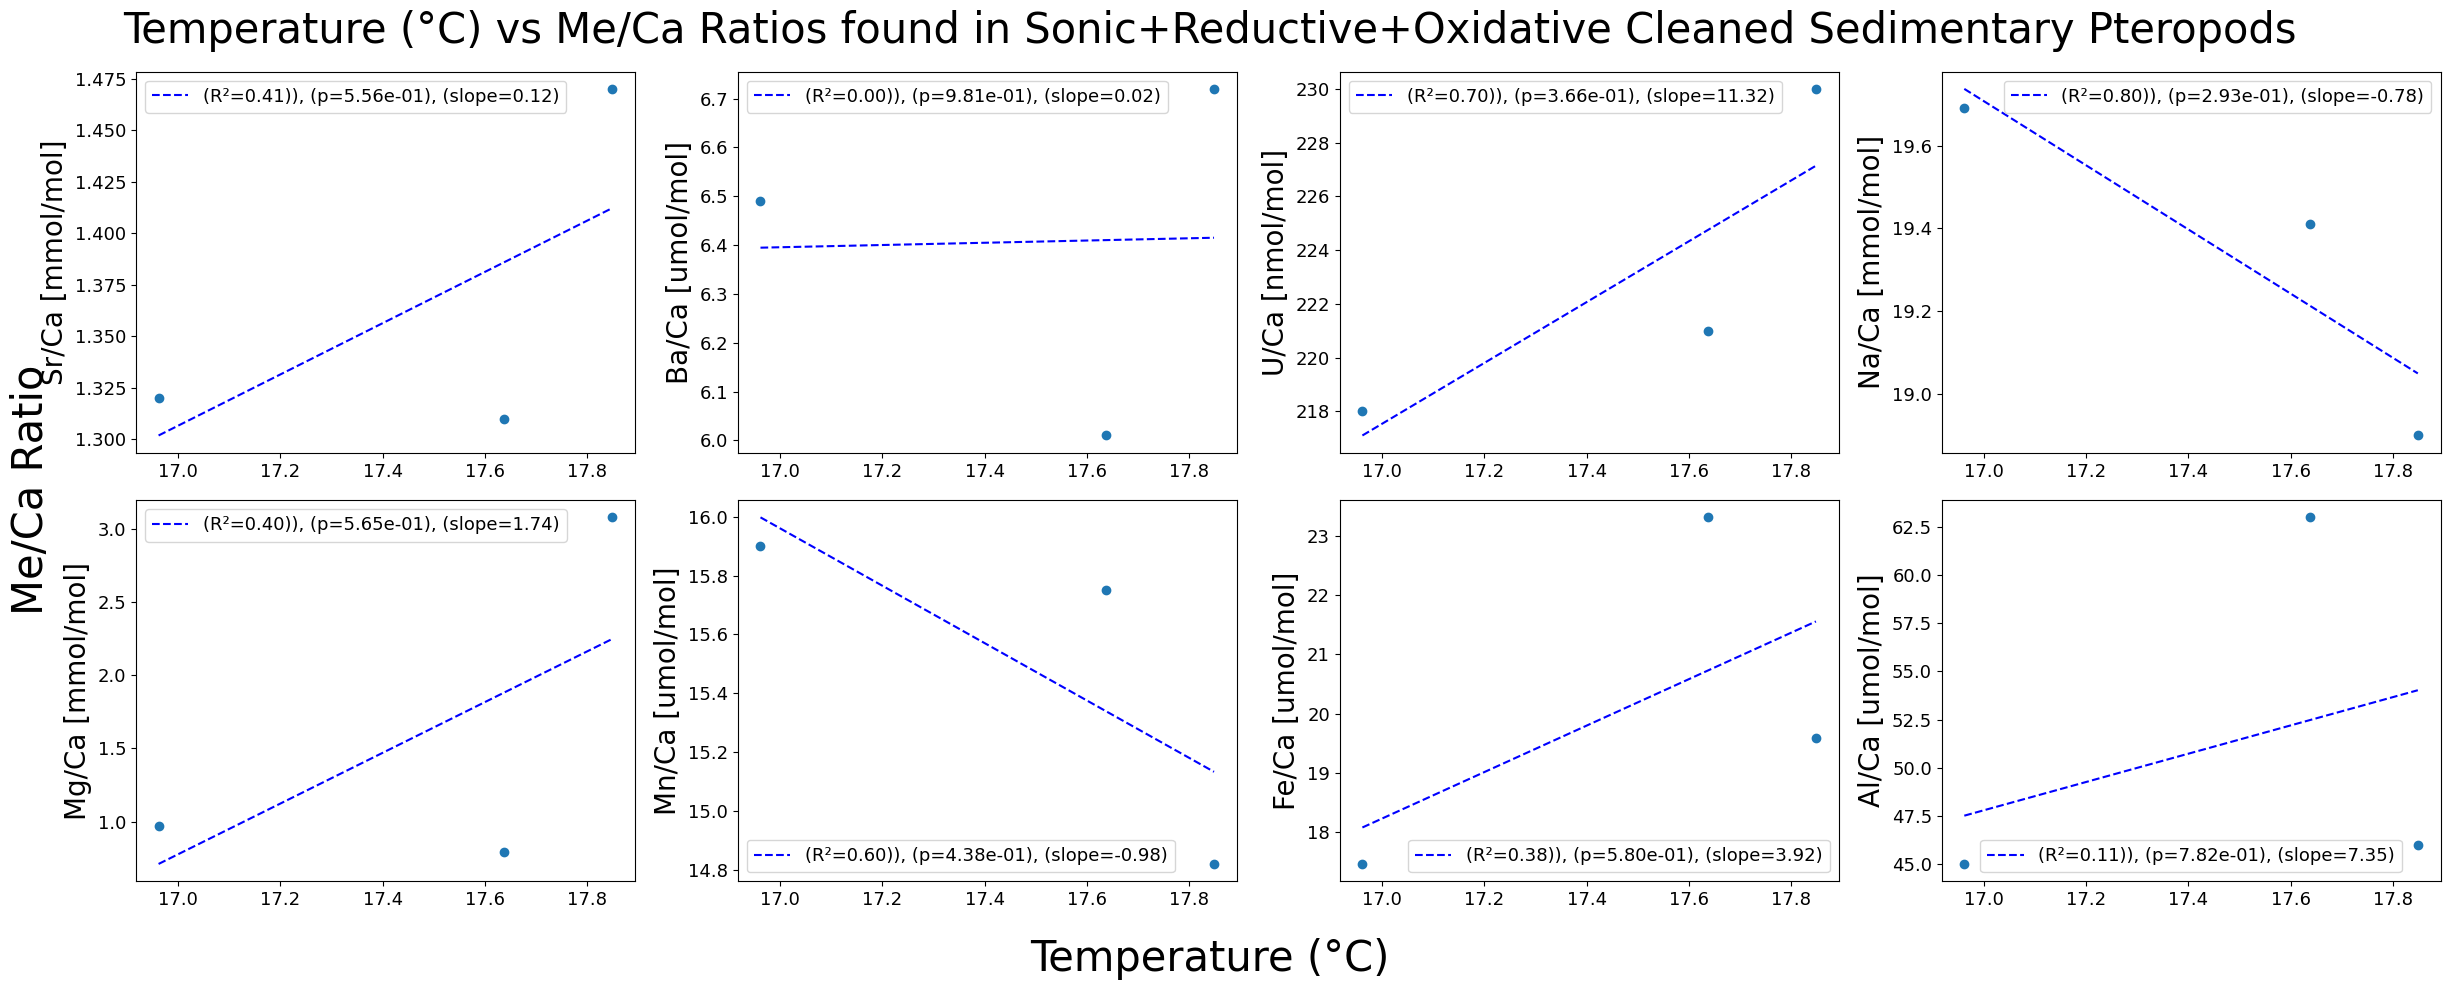

In [35]:
#graph 22: me/ca vs temp in ox+red+sonic pteropods

#Graph 17: linear regression of temperature vs red+sonic pteropods Me/Ca ratios

#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()

#redsonic 
ax1.scatter(oxredsonict, Srredox)

ax2.scatter(oxredsonict, Baredox)

ax3.scatter(oxredsonict, Uredox)

ax4.scatter(oxredsonict, Naredox)

ax5.scatter(oxredsonict, Mgredox)

ax6.scatter(oxredsonict, Mnredox)

ax7.scatter(oxredsonict, Feredox) 

ax8.scatter(oxredsonict, Alredox)

# calulate linear regression 
slopeoxredSr, interceptoxredSr, r_valueoxredSr, p_valueoxredSr, std_erroxredSr = linregress( oxredsonict, Srredox)
regression_yoxredSr = slopeoxredSr * oxredsonict + interceptoxredSr
r_squaredoxredSr = r_valueoxredSr**2

slopeoxredBa, interceptoxredBa, r_valueoxredBa, p_valueoxredBa, std_erroxredBa = linregress(oxredsonict, Baredox)
regression_yoxredBa = slopeoxredBa * oxredsonict + interceptoxredBa
r_squaredoxredBa = r_valueoxredBa**2

slopeoxredU, interceptoxredU, r_valueoxredU, p_valueoxredU, std_erroxredU = linregress(oxredsonict, Uredox)
regression_yoxredU = slopeoxredU * oxredsonict + interceptoxredU
r_squaredoxredU = r_valueoxredU**2

slopeoxredNa, interceptoxredNa, r_valueoxredNa, p_valueoxredNa, std_erroxredNa = linregress(oxredsonict, Naredox)
regression_yoxredNa = slopeoxredNa * oxredsonict + interceptoxredNa
r_squaredoxredNa = r_valueoxredNa**2

slopeoxredMg, interceptoxredMg, r_valueoxredMg, p_valueoxredMg, std_erroxredMg = linregress(oxredsonict, Mgredox)
regression_yoxredMg = slopeoxredMg * oxredsonict + interceptoxredMg
r_squaredoxredMg = r_valueoxredMg**2

slopeoxredMn, interceptoxredMn, r_valueoxredMn, p_valueoxredMn, std_erroxredMn = linregress(oxredsonict, Mnredox)
regression_yoxredMn = slopeoxredMn * oxredsonict + interceptoxredMn
r_squaredoxredMn = r_valueoxredMn**2

slopeoxredFe, interceptoxredFe, r_valueoxredFe, p_valueoxredFe, std_erroxredFe = linregress(oxredsonict, Feredox)
regression_yoxredFe = slopeoxredFe * oxredsonict + interceptoxredFe
r_squaredoxredFe = r_valueoxredFe**2

slopeoxredAl, interceptoxredAl, r_valueoxredAl, p_valueoxredAl, std_erroxredAl = linregress(oxredsonict, Alredox)
regression_yoxredAl = slopeoxredAl * oxredsonict+ interceptoxredAl
r_squaredoxredAl = r_valueoxredAl**2

#plot linear regression 
ax1.plot(oxredsonict, regression_yoxredSr, label=f'(R²={r_squaredoxredSr:.2f})), (p={p_valueoxredSr:.2e}), (slope={slopeoxredSr:.2f})', color='b', linestyle='--')

ax2.plot(oxredsonict, regression_yoxredBa, label=f'(R²={r_squaredoxredBa:.2f})), (p={p_valueoxredBa:.2e}), (slope={slopeoxredBa:.2f})', color='b', linestyle='--')

ax3.plot(oxredsonict, regression_yoxredU, label=f'(R²={r_squaredoxredU:.2f})), (p={p_valueoxredU:.2e}), (slope={slopeoxredU:.2f})', color='b', linestyle='--')

ax4.plot(oxredsonict, regression_yoxredNa, label=f'(R²={r_squaredoxredNa:.2f})), (p={p_valueoxredNa:.2e}), (slope={slopeoxredNa:.2f})', color='b', linestyle='--')

ax5.plot(oxredsonict, regression_yoxredMg, label=f'(R²={r_squaredoxredMg:.2f})), (p={p_valueoxredMg:.2e}), (slope={slopeoxredMg:.2f})', color='b', linestyle='--')

ax6.plot(oxredsonict, regression_yoxredMn, label=f'(R²={r_squaredoxredMn:.2f})), (p={p_valueoxredMn:.2e}), (slope={slopeoxredMn:.2f})', color='b', linestyle='--')

ax7.plot(oxredsonict, regression_yoxredFe, label=f'(R²={r_squaredoxredFe:.2f})), (p={p_valueoxredFe:.2e}), (slope={slopeoxredFe:.2f})', color='b', linestyle='--')

ax8.plot(oxredsonict, regression_yoxredAl, label=f'(R²={r_squaredoxredAl:.2f})), (p={p_valueoxredAl:.2e}), (slope={slopeoxredAl:.2f})', color='b', linestyle='--')



#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')



#plot title
fig.suptitle('Temperature (°C) vs Me/Ca Ratios found in Sonic+Reductive+Oxidative Cleaned Sedimentary Pteropods', fontsize = 30)
fig.supxlabel('Temperature (°C)', fontsize= 30)
fig.supylabel ('Me/Ca Ratio', fontsize = 30)
#fixing spacing layout
fig.tight_layout()

#add legend
ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()
ax5.legend()
ax6.legend()
ax7.legend()
ax8.legend()

